In [1]:
!mkdir -p ~/work/object_detection/data
!ln -s ~/data/* ~/work/object_detection/data

ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/checkpoints': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/downloads': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/go_1.png': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/go_2.png': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/go_3.png': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/go_4.png': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/go_5.png': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/kitti': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/stop_1.png': File exists
ln: failed to create symbolic link '/home/jovyan/work/object_detection/data/stop_2.png': File exists
ln: f

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.datasets import Kitti
import torchvision.models as models
from torchvision.ops import nms

import os, copy, time
import numpy as np
import random
from typing import Dict, List, Tuple, Optional, Callable
import argparse
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

print('슝=3')

슝=3


In [3]:
DATA_DIR = os.path.join(os.getenv("HOME"), "work/object_detection/data")  # 여기 아래에 Kitti/raw/... 구조가 생김

transform = transforms.Compose([
    transforms.ToTensor(),   # PIL → torch.Tensor [0, 1]
])

def target_transform(target):
    # 입력된 label 정보를 변환하기 위한 기능
    # target: list[dict], 각 dict에 keys: type, truncated, occluded, alpha, bbox, dimensions, location, rotation_y
    # 예: 여기서는 일단 그대로 반환
    return target

train_dataset = Kitti(
    root=DATA_DIR,
    train=True,
    transform=transform,
    target_transform=target_transform,  # 필요 없으면 None
    download=True,                      # 한 번만 True면 됨
)
test_dataset = Kitti(
    root=DATA_DIR,
    train=False,
    transform=transform,
    target_transform=None,
    download=False,
)
print("Train data samples: ", len(train_dataset))
print("Test data samples: ", len(test_dataset))
print('슝=3')

100%|██████████| 12.6G/12.6G [12:59<00:00, 16.1MB/s]  
100%|██████████| 5.60M/5.60M [00:01<00:00, 3.32MB/s]


Train data samples:  7481
Test data samples:  7518
슝=3


Image index: 2379
------Example------


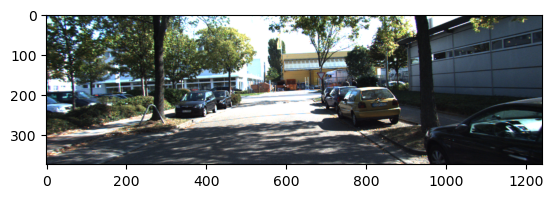

torch.Size([3, 375, 1242])
['type', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y']

------objects------
[{'type': 'Car', 'truncated': 0.96, 'occluded': 0, 'alpha': -2.33, 'bbox': [933.46, 184.83, 1241.0, 374.0], 'dimensions': [1.46, 1.67, 3.89], 'location': [3.22, 1.54, 3.33], 'rotation_y': -1.61}, {'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': 1.9, 'bbox': [317.05, 189.17, 432.98, 261.68], 'dimensions': [1.56, 1.63, 3.62], 'location': [-5.74, 2.0, 17.94], 'rotation_y': 1.59}, {'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': -1.85, 'bbox': [727.81, 177.41, 893.29, 287.55], 'dimensions': [1.51, 1.6, 3.54], 'location': [3.03, 1.6, 11.79], 'rotation_y': -1.6}, {'type': 'Car', 'truncated': 0.0, 'occluded': 2, 'alpha': -1.85, 'bbox': [695.21, 177.9, 797.53, 249.66], 'dimensions': [1.53, 1.5, 3.34], 'location': [3.11, 1.67, 17.28], 'rotation_y': -1.67}, {'type': 'Car', 'truncated': 0.0, 'occluded': 2, 'alpha': 1.8, 'bbox': [396.59, 189.0

In [4]:
idx = random.randint(0, len(train_dataset)-1)   # 한 장의 샘플 데이터를 무작위로 추출합니다.
sample = train_dataset[idx]

print("Image index:", idx)

print('------Example------')
image = sample[0]
img = TF.to_pil_image(image)
plt.imshow(img)
plt.show()
print(np.shape(image))
print(list(sample[1][0].keys()))

print('\n------objects------')
objects = sample[1]
print(objects)

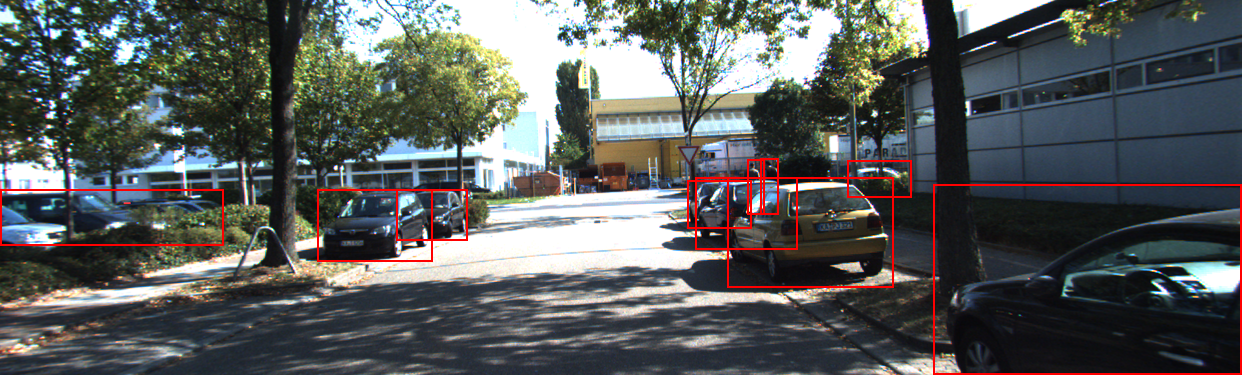

In [5]:
# 이미지 위에 바운딩 박스를 그려 화면에 표시해 주세요.
def visualize_bbox(input_image, objects):
    input_image = copy.deepcopy(input_image)
    draw = ImageDraw.Draw(input_image)

    for _obj in objects:
        # 바운딩 박스 좌표(x_min, x_max, y_min, y_max) 구하기
        height, width, _ = np.shape(input_image)
        x_min, y_min, x_max, y_max = _obj['bbox']
        
        # 바운딩 박스 그리기
        draw.rectangle([x_min, y_min, x_max, y_max], outline=(255,0,0), width=2)

    return input_image

visualize_bbox(img, objects)

In [6]:
class KITTIDataset(Dataset):
    """
    KITTI 객체 탐지 데이터셋
    
    Args:
        img_dir: 이미지 디렉토리 경로
        label_dir: 레이블 디렉토리 경로
        classes: 사용할 클래스 리스트 (None이면 모든 클래스 사용)
        exclude_dontcare: DontCare 객체 제외 여부
    """
    
    # KITTI 데이터셋의 모든 클래스
    ALL_CLASSES = [
        'Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 
        'Cyclist', 'Tram', 'Misc', 'DontCare'
    ]
    
    def __init__(
        self,
        img_dir: str,
        label_dir: str,
        classes: Optional[List[str]] = None,
        exclude_dontcare: bool = True
    ):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.exclude_dontcare = exclude_dontcare
        
        # 사용할 클래스 설정
        if classes is None:
            self.classes = [c for c in self.ALL_CLASSES if c != 'DontCare']
        else:
            self.classes = classes
            
        # 클래스명 -> 인덱스 매핑 (0부터 시작)
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.idx_to_class = {idx: cls_name for cls_name, idx in self.class_to_idx.items()}
        
        # 이미지 파일 리스트 가져오기
        self.image_files = self._get_image_files()
        
        print(f"KITTIDataset 초기화 완료:")
        print(f"  - 이미지 개수: {len(self.image_files)}")
        print(f"  - 클래스 개수: {len(self.classes)}")
        print(f"  - 클래스: {self.classes}")
        
    def _get_image_files(self) -> List[str]:
        """이미지 파일 목록을 가져오고 검증합니다."""
        image_files = []
        
        # 이미지 디렉토리의 모든 PNG 파일 찾기
        for fname in sorted(os.listdir(self.img_dir)):
            if fname.endswith('.png') or fname.endswith('.jpg'):
                img_path = os.path.join(self.img_dir, fname)
                label_path = os.path.join(self.label_dir, fname.replace('.png', '.txt').replace('.jpg', '.txt'))
                
                # 이미지와 레이블 모두 존재하는지 확인
                if os.path.exists(img_path) and os.path.exists(label_path):
                    image_files.append(fname)
                else:
                    print(f"경고: {fname}의 레이블 파일이 없습니다.")
                    
        return image_files
    
    def _parse_label(self, label_path: str) -> Tuple[np.ndarray, np.ndarray]:
        """
        레이블 파일을 파싱하여 bbox와 클래스 정보를 추출합니다.
        
        Returns:
            boxes: (N, 4) numpy array of [x_min, y_min, x_max, y_max]
            labels: (N,) numpy array of class indices
        """
        boxes = []
        labels = []
        
        if not os.path.exists(label_path):
            return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                    
                parts = line.split()
                if len(parts) < 15:
                    continue
                
                class_name = parts[0]
                
                # DontCare 제외 옵션 처리
                if self.exclude_dontcare and class_name == 'DontCare':
                    continue
                
                # 사용할 클래스에 포함되지 않으면 스킵
                if class_name not in self.class_to_idx:
                    continue
                
                # Bounding box 좌표 (2D bbox)
                try:
                    bbox = [float(parts[4]), float(parts[5]), 
                           float(parts[6]), float(parts[7])]
                    
                    # 유효한 bbox인지 확인
                    if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                        boxes.append(bbox)
                        labels.append(self.class_to_idx[class_name])
                except (ValueError, IndexError):
                    continue
        
        if len(boxes) == 0:
            return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        
        return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)
    
    def __len__(self) -> int:
        """데이터셋의 크기를 반환합니다."""
        return len(self.image_files)
    
    def __getitem__(self, idx: int) -> Dict:
        """
        인덱스에 해당하는 샘플을 반환합니다.
        
        Returns:
            dict: {
                'image': PIL.Image,
                'boxes': np.ndarray (N, 4),
                'labels': np.ndarray (N,),
                'image_id': str
            }
        """
        # 파일명 가져오기
        fname = self.image_files[idx]
        img_path = os.path.join(self.img_dir, fname)
        label_path = os.path.join(self.label_dir, fname.replace('.png', '.txt').replace('.jpg', '.txt'))
        
        # 이미지 로드
        image = Image.open(img_path).convert('RGB')
        
        # 레이블 파싱
        boxes, labels = self._parse_label(label_path)
        
        # 결과 딕셔너리 생성
        target = {
            'image': image,
            'boxes': boxes,
            'labels': labels,
            'image_id': fname.replace('.png', '').replace('.jpg', '')
        }
        
        return target
    
    def get_class_name(self, idx: int) -> str:
        """클래스 인덱스를 클래스 이름으로 변환합니다."""
        return self.idx_to_class.get(idx, 'Unknown')
    
    def get_num_classes(self) -> int:
        """클래스 개수를 반환합니다 (배경 제외)."""
        return len(self.classes)

In [7]:
class RandomHorizontalFlip:
    """랜덤 좌우 반전 + bbox 좌표 조정."""
    
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, image, target):
        if random.random() < self.p:
            # 이미지가 PIL인지 Tensor인지 확인
            if isinstance(image, Image.Image):
                image = TF.hflip(image)
                width, _ = image.size
            else:  # Tensor
                image = TF.hflip(image)
                _, _, width = image.shape
            
            # Bounding box 좌표 변환
            boxes = target['boxes'].copy()
            if len(boxes) > 0:
                boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
                target['boxes'] = boxes
        
        return image, target

class ColorJitter:
    """색상 변환: 밝기, 대비, 채도, 색조 조정."""
    
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.hue = hue
    
    def __call__(self, image, target):
        # PIL Image에만 적용 (Tensor 이전에 적용되어야 함)
        if isinstance(image, Image.Image):
            if self.brightness > 0:
                brightness_factor = random.uniform(1 - self.brightness, 1 + self.brightness)
                image = TF.adjust_brightness(image, brightness_factor)
            
            if self.contrast > 0:
                contrast_factor = random.uniform(1 - self.contrast, 1 + self.contrast)
                image = TF.adjust_contrast(image, contrast_factor)
            
            if self.saturation > 0:
                saturation_factor = random.uniform(1 - self.saturation, 1 + self.saturation)
                image = TF.adjust_saturation(image, saturation_factor)
            
            if self.hue > 0:
                hue_factor = random.uniform(-self.hue, self.hue)
                image = TF.adjust_hue(image, hue_factor)
        
        return image, target

In [8]:
class Resize:
    """고정 크기로 리사이즈 + bbox 스케일링."""
    
    def __init__(self, size: Tuple[int, int]):
        """
        Args:
            size: (height, width) tuple
        """
        self.size = size  # (H, W)
    
    def __call__(self, image, target):
        # 원본 크기
        if isinstance(image, Image.Image):
            orig_width, orig_height = image.size
            image = TF.resize(image, self.size)
        else:  # Tensor
            _, orig_height, orig_width = image.shape
            image = TF.resize(image, self.size)
        
        # 스케일 계산
        new_height, new_width = self.size
        scale_y = new_height / orig_height
        scale_x = new_width / orig_width
        
        # Bounding box 스케일링
        boxes = target['boxes'].copy()
        if len(boxes) > 0:
            boxes[:, 0] *= scale_x  # x_min
            boxes[:, 1] *= scale_y  # y_min
            boxes[:, 2] *= scale_x  # x_max
            boxes[:, 3] *= scale_y  # y_max
            target['boxes'] = boxes
        
        return image, target

class RandomCrop:
    """랜덤 크롭 + bbox 클리핑 및 유효성 검증."""
    
    def __init__(self, size: Tuple[int, int], min_area_ratio=0.3):
        """
        Args:
            size: (height, width) 크롭 크기
            min_area_ratio: 크롭 후 최소 면적 비율 (원본 대비)
        """
        self.size = size
        self.min_area_ratio = min_area_ratio
    
    def __call__(self, image, target):
        # 원본 크기
        if isinstance(image, Image.Image):
            orig_width, orig_height = image.size
        else:
            _, orig_height, orig_width = image.shape
        
        crop_height, crop_width = self.size
        
        # 이미지가 크롭 크기보다 작으면 패딩
        if orig_height < crop_height or orig_width < crop_width:
            # 패딩 없이 리사이즈로 처리
            resize_transform = Resize(self.size)
            return resize_transform(image, target)
        
        # 랜덤 크롭 위치
        top = random.randint(0, orig_height - crop_height)
        left = random.randint(0, orig_width - crop_width)
        
        # 이미지 크롭
        if isinstance(image, Image.Image):
            image = TF.crop(image, top, left, crop_height, crop_width)
        else:
            image = TF.crop(image, top, left, crop_height, crop_width)
        
        # Bounding box 조정
        boxes = target['boxes'].copy()
        labels = target['labels'].copy()
        
        if len(boxes) > 0:
            # 크롭 영역으로 좌표 변환
            boxes[:, 0] -= left  # x_min
            boxes[:, 1] -= top   # y_min
            boxes[:, 2] -= left  # x_max
            boxes[:, 3] -= top   # y_max
            
            # 크롭 영역 내로 클리핑
            boxes[:, 0] = np.clip(boxes[:, 0], 0, crop_width)
            boxes[:, 1] = np.clip(boxes[:, 1], 0, crop_height)
            boxes[:, 2] = np.clip(boxes[:, 2], 0, crop_width)
            boxes[:, 3] = np.clip(boxes[:, 3], 0, crop_height)
            
            # 유효한 bbox만 유지 (최소 면적 체크)
            areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            orig_areas = (target['boxes'][:, 2] - target['boxes'][:, 0]) * \
                        (target['boxes'][:, 3] - target['boxes'][:, 1])
            
            valid_mask = (boxes[:, 2] > boxes[:, 0]) & \
                        (boxes[:, 3] > boxes[:, 1]) & \
                        (areas >= orig_areas * self.min_area_ratio)
            
            boxes = boxes[valid_mask]
            labels = labels[valid_mask]
        
        target['boxes'] = boxes
        target['labels'] = labels
        
        return image, target


In [9]:
class ToTensor:
    """PIL Image를 Tensor로 변환합니다."""
    
    def __call__(self, image, target):
        image = TF.to_tensor(image)
        return image, target


class Normalize:
    """이미지를 정규화합니다 (ImageNet 평균/표준편차)."""
    
    def __init__(self, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
        self.mean = mean
        self.std = std
    
    def __call__(self, image, target):
        image = TF.normalize(image, mean=self.mean, std=self.std)
        return image, target

In [10]:
class ToTensor:
    """PIL Image를 Tensor로 변환합니다."""
    
    def __call__(self, image, target):
        image = TF.to_tensor(image)
        return image, target


class Normalize:
    """이미지를 정규화합니다 (ImageNet 평균/표준편차)."""
    
    def __init__(self, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
        self.mean = mean
        self.std = std
    
    def __call__(self, image, target):
        image = TF.normalize(image, mean=self.mean, std=self.std)
        return image, target

In [11]:
class Compose:
    """여러 변환을 순차적으로 적용합니다."""
    
    def __init__(self, transforms: List[Callable]):
        self.transforms = transforms
    
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

def collate_fn(batch: List[Dict]) -> Tuple[torch.Tensor, List[Dict]]:
    """
    배치 생성을 위한 커스텀 collate 함수.
    이미지 크기가 다를 수 있으므로 리스트로 반환합니다.
    Args:
        batch: 샘플 리스트
    Returns:
        images: (B, C, H, W) Tensor
        targets: 타겟 딕셔너리 리스트
    """
    images = []
    targets = []
    
    for item in batch:
        images.append(item['image'])
        targets.append({
            'boxes': torch.tensor(item['boxes'], dtype=torch.float32),
            'labels': torch.tensor(item['labels'], dtype=torch.int64),
            'image_id': item['image_id']
        })
    
    # 이미지를 스택 (모두 같은 크기여야 함)
    images = torch.stack(images, dim=0)
    return images, targets

class TransformedDataset:
    """Transform을 적용하는 데이터셋 래퍼."""
    
    def __init__(self, dataset: KITTIDataset, transform: Optional[Callable] = None):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample['image']
        target = {
            'boxes': sample['boxes'],
            'labels': sample['labels'],
            'image_id': sample['image_id']
        }
        
        if self.transform is not None:
            image, target = self.transform(image, target)
        
        return {
            'image': image,
            'boxes': target['boxes'],
            'labels': target['labels'],
            'image_id': target['image_id']
        }

def get_train_transforms(img_size=(600, 800)):
    """훈련용 데이터 변환 파이프라인."""
    return Compose([
        # RandomResize(min_size=580, max_size=620), 필요없는 증강.
        RandomHorizontalFlip(p=0.3),
        ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        Resize(img_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_val_transforms(img_size=(600, 800)):
    """검증용 데이터 변환 파이프라인 (증강 없음)."""
    return Compose([
        Resize(img_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [12]:
def get_train_dataloader(
    img_dir: str,
    label_dir: str,
    batch_size: int = 8,
    num_workers: int = 4,
    img_size: Tuple[int, int] = (600, 800),
    shuffle: bool = True,
    classes: Optional[List[str]] = None
) -> DataLoader:
    """
    훈련용 DataLoader를 생성합니다.
    Args:
        img_dir: 이미지 디렉토리
        label_dir: 레이블 디렉토리
        batch_size: 배치 크기
        num_workers: 워커 프로세스 수
        img_size: 이미지 크기 (height, width)
        shuffle: 셔플 여부
        classes: 사용할 클래스 리스트
    Returns:
        DataLoader
    """
    dataset = KITTIDataset(
        img_dir=img_dir,
        label_dir=label_dir,
        classes=classes,
        exclude_dontcare=True
    )
    
    transformed_dataset = TransformedDataset(
        dataset=dataset,
        transform=get_train_transforms(img_size)
    )
    
    return DataLoader(
        transformed_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True
    )

def get_val_dataloader(
    img_dir: str,
    label_dir: str,
    batch_size: int = 8,
    num_workers: int = 4,
    img_size: Tuple[int, int] = (600, 800),
    shuffle: bool = False,
    classes: Optional[List[str]] = None
) -> DataLoader:
    """
    검증용 DataLoader를 생성합니다.
    Args:
        img_dir: 이미지 디렉토리
        label_dir: 레이블 디렉토리
        batch_size: 배치 크기
        num_workers: 워커 프로세스 수
        img_size: 이미지 크기 (height, width)
        shuffle: 셔플 여부
        classes: 사용할 클래스 리스트
    Returns:
        DataLoader
    """
    dataset = KITTIDataset(
        img_dir=img_dir,
        label_dir=label_dir,
        classes=classes,
        exclude_dontcare=True
    )
    
    transformed_dataset = TransformedDataset(
        dataset=dataset,
        transform=get_val_transforms(img_size)
    )
    
    return DataLoader(
        transformed_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True
    )

In [13]:
class AnchorBox:
    """
    RetinaNet을 위한 Anchor Box 생성기
    Args:
        aspect_ratios: Anchor의 가로세로 비율 리스트
        scales: Anchor 크기 스케일 리스트
        areas: 각 피라미드 레벨별 기본 영역
    """
    
    def __init__(
        self,
        aspect_ratios=[0.5, 1.0, 2.0],
        scales=[2 ** 0, 2 ** (1/3), 2 ** (2/3)],
        areas=[32.0**2, 64.0**2, 128.0**2, 256.0**2, 512.0**2]
    ):
        self.aspect_ratios = aspect_ratios
        self.scales = scales
        self.areas = areas
        
        self._num_anchors = len(aspect_ratios) * len(scales)
        self._strides = [2 ** i for i in range(3, 8)]  # [8, 16, 32, 64, 128]
        self._anchor_dims = self._compute_dims()
    
    def _compute_dims(self):
        """각 피라미드 레벨과 aspect ratio/scale 조합별 anchor 크기 계산"""
        anchor_dims_all = []
        
        for area in self.areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area / ratio))
                anchor_width = area / anchor_height
                
                dims = torch.stack([anchor_width, anchor_height], dim=-1)
                dims = dims.unsqueeze(0).unsqueeze(0)
                
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))
        
        return anchor_dims_all
    
    def _get_anchors(self, feature_height, feature_width, level):
        """특정 피라미드 레벨의 anchor boxes 생성"""
        # 그리드 중심점 생성
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        
        centers = torch.stack(torch.meshgrid(rx, ry, indexing='xy'), dim=-1)
        centers = centers * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        
        # Anchor 크기 정보
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        
        # [center_x, center_y, width, height] 형식
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)
    
    def get_anchors(self, image_height, image_width):
        """이미지 크기에 대한 모든 피라미드 레벨의 anchors 생성"""
        anchors = [
            self._get_anchors(
                torch.ceil(torch.tensor(image_height / (2 ** i))).int().item(),
                torch.ceil(torch.tensor(image_width / (2 ** i))).int().item(),
                i
            )
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)

In [14]:
def convert_to_corners(boxes):
    """중심점 형식을 corner 형식으로 변환"""
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0,
         boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1
    )

def convert_to_xywh(boxes):
    """Corner 형식을 중심점 형식으로 변환"""
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

In [15]:
class LabelEncoder:
    """
    Ground truth boxes와 labels를 anchor boxes에 매칭하여 학습용 타겟 생성
    """
    
    def __init__(self, box_variance=[0.1, 0.1, 0.2, 0.2]):
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)
    
    def _compute_iou(self, boxes1, boxes2):
        """IoU 계산 (boxes format: [x_min, y_min, x_max, y_max])"""
        # Intersection
        lu = torch.maximum(boxes1[:, None, :2], boxes2[:, :2])
        rd = torch.minimum(boxes1[:, None, 2:], boxes2[:, 2:])
        intersection = torch.clamp(rd - lu, min=0.0)
        intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
        
        # Areas
        boxes1_area = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
        boxes2_area = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
        
        # Union
        union_area = boxes1_area[:, None] + boxes2_area - intersection_area
        
        return intersection_area / torch.clamp(union_area, min=1e-8)
    
    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        """Anchor boxes를 ground truth boxes에 매칭"""
        # Convert anchors from [cx, cy, w, h] to [x_min, y_min, x_max, y_max]
        anchor_corners = torch.cat([
            anchor_boxes[:, :2] - anchor_boxes[:, 2:] / 2.0,
            anchor_boxes[:, :2] + anchor_boxes[:, 2:] / 2.0
        ], dim=-1)
        
        iou_matrix = self._compute_iou(anchor_corners, gt_boxes)
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        
        positive_mask = max_iou >= match_iou
        negative_mask = max_iou < ignore_iou
        ignore_mask = ~(positive_mask | negative_mask)
        
        return matched_gt_idx, positive_mask.float(), ignore_mask.float()
    
    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        """Anchor box와 GT box 간의 offset 계산"""
        # Convert GT boxes to [cx, cy, w, h]
        matched_gt_cxcywh = torch.cat([
            (matched_gt_boxes[:, :2] + matched_gt_boxes[:, 2:]) / 2.0,
            matched_gt_boxes[:, 2:] - matched_gt_boxes[:, :2]
        ], dim=-1)
        
        box_target = torch.cat([
            (matched_gt_cxcywh[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
            torch.log(matched_gt_cxcywh[:, 2:] / anchor_boxes[:, 2:])
        ], dim=-1)
        
        box_target = box_target / self._box_variance.to(box_target.device)
        
        return box_target
    
    def encode_batch(self, images, batch_boxes, batch_labels):
        """
        배치 데이터를 인코딩
        
        Args:
            images: (B, C, H, W) 이미지
            batch_boxes: List of (N, 4) boxes per image
            batch_labels: List of (N,) labels per image
        
        Returns:
            encoded_labels: (B, num_anchors, 5) encoded targets
        """
        batch_size = images.size(0)
        image_height, image_width = images.size(2), images.size(3)
        
        anchor_boxes = self._anchor_box.get_anchors(image_height, image_width)
        anchor_boxes = anchor_boxes.to(images.device)
        
        encoded_labels = []
        
        for i in range(batch_size):
            gt_boxes = batch_boxes[i].to(images.device)
            cls_ids = batch_labels[i].to(images.device).float()
            
            if len(gt_boxes) == 0:
                # No objects in this image
                label = torch.zeros((len(anchor_boxes), 5), device=images.device)
                label[:, 4] = -1.0  # All negative
                encoded_labels.append(label)
                continue
            
            matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(
                anchor_boxes, gt_boxes
            )
            
            matched_gt_boxes = gt_boxes[matched_gt_idx]
            box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
            
            matched_gt_cls_ids = cls_ids[matched_gt_idx]
            cls_target = torch.where(positive_mask != 1.0, -1.0, matched_gt_cls_ids)
            cls_target = torch.where(ignore_mask == 1.0, -2.0, cls_target)
            
            label = torch.cat([box_target, cls_target.unsqueeze(-1)], dim=-1)
            encoded_labels.append(label)
        
        return torch.stack(encoded_labels, dim=0)

print('슝=3')

슝=3


In [16]:
class FeaturePyramid(nn.Module):
    """
    Feature Pyramid Network
    ResNet 백본에서 추출한 feature maps를 피라미드 구조로 변환
    """
    
    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # 1x1 convolution for lateral connections
        self.conv_c3_1x1 = nn.Conv2d(512, 256, kernel_size=1, stride=1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, kernel_size=1, stride=1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, kernel_size=1, stride=1, padding=0)
        # 3x3 convolution for smoothing
        self.conv_c3_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        # Extra layers for P6, P7
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, kernel_size=3, stride=2, padding=1)
        self.conv_c7_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')
    
    def forward(self, images):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지
        Returns:
            p3, p4, p5, p6, p7: 5개 레벨의 feature maps
        """
        # ResNet backbone feature extraction
        c3_output, c4_output, c5_output = self.backbone(images)        
        # Top-down pathway
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p3_output = self.conv_c3_1x1(c3_output)
        # Add upsampled features (크기를 맞춰서 더하기)
        p5_upsampled = F.interpolate(p5_output, size=p4_output.shape[-2:], mode='nearest')
        p4_output = p4_output + p5_upsampled
        p4_upsampled = F.interpolate(p4_output, size=p3_output.shape[-2:], mode='nearest')
        p3_output = p3_output + p4_upsampled
        # Apply 3x3 smoothing
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        # Extra coarse levels
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(F.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output


In [17]:
def build_head(output_filters, bias_init, num_convs=4):
    """
    분류 또는 박스 회귀 헤드 구축
    Args:
        output_filters: 출력 채널 수
        bias_init: 마지막 레이어의 bias 초기화 값
        num_convs: convolution 레이어 개수
    """
    layers = []
    
    for _ in range(num_convs):
        layers.append(nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1))
        layers.append(nn.ReLU(inplace=True))
    # 최종 예측 레이어
    layers.append(nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1))
    
    # Weight 초기화
    for layer in layers:
        if isinstance(layer, nn.Conv2d):
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)
    # 마지막 레이어 bias 초기화
    if isinstance(bias_init, (int, float)):
        nn.init.constant_(layers[-1].bias, bias_init)
    
    return nn.Sequential(*layers)

In [18]:
def build_head(output_filters, bias_init, num_convs=4):
    """
    분류 또는 박스 회귀 헤드 구축
    Args:
        output_filters: 출력 채널 수
        bias_init: 마지막 레이어의 bias 초기화 값
        num_convs: convolution 레이어 개수
    """
    layers = []
    
    for _ in range(num_convs):
        layers.append(nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1))
        layers.append(nn.ReLU(inplace=True))
    # 최종 예측 레이어
    layers.append(nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1))
    
    # Weight 초기화
    for layer in layers:
        if isinstance(layer, nn.Conv2d):
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)
    # 마지막 레이어 bias 초기화
    if isinstance(bias_init, (int, float)):
        nn.init.constant_(layers[-1].bias, bias_init)
    
    return nn.Sequential(*layers)

In [19]:
class RetinaNet(nn.Module):
    """
    RetinaNet 객체 탐지 모델
    Args:
        num_classes: 객체 클래스 개수 (배경 제외)
        backbone: Feature 추출을 위한 백본 네트워크
    """

    def __init__(self, num_classes, backbone=None):
        super(RetinaNet, self).__init__()        
        if backbone is None:
            backbone = get_resnet50_backbone(pretrained=True)
        
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes
        # Prior probability for rare class
        prior_probability = 0.01
        bias_value = -np.log((1 - prior_probability) / prior_probability)
        # 9 = 3 aspect ratios * 3 scales
        self.cls_head = build_head(9 * num_classes, bias_value)
        self.box_head = build_head(9 * 4, 0.0)
    
    def forward(self, images):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지        
        Returns:
            predictions: (B, num_anchors, 4 + num_classes)
                - 처음 4개: bbox 회귀 예측
                - 나머지: 클래스 로짓
        """
        features = self.fpn(images)
        N = images.size(0)
        cls_outputs = []
        box_outputs = []
        
        for feature in features:
            box_output = self.box_head(feature)
            cls_output = self.cls_head(feature)
            
            # Reshape: (B, C, H, W) -> (B, H*W*9, 4 or num_classes)
            box_output = box_output.permute(0, 2, 3, 1).contiguous()
            box_output = box_output.view(N, -1, 4)
            cls_output = cls_output.permute(0, 2, 3, 1).contiguous()
            cls_output = cls_output.view(N, -1, self.num_classes)
            
            box_outputs.append(box_output)
            cls_outputs.append(cls_output)
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

In [20]:
class RetinaNetBoxLoss(nn.Module):
    """Smooth L1 Loss for bounding box regression"""
    def __init__(self, delta=1.0):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta
    
    def forward(self, y_true, y_pred):
        """
        Args:
            y_true: (B, num_anchors, 4) ground truth boxes
            y_pred: (B, num_anchors, 4) predicted boxes
        Returns:
            loss: (B, num_anchors) box regression loss
        """
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5
        )
        return torch.sum(loss, dim=-1)

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance
    Args:
        alpha: 클래스 가중치 (일반적으로 0.25)
        gamma: focusing parameter (일반적으로 2.0)
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma
    
    def forward(self, y_true, y_pred):
        """
        Args:
            y_true: (B, num_anchors, num_classes) one-hot encoded labels
            y_pred: (B, num_anchors, num_classes) predicted logits
        Returns:
            loss: (B, num_anchors) focal loss
        """
        cross_entropy = F.binary_cross_entropy_with_logits(
            y_pred, y_true, reduction='none'
        )
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true == 1.0, self._alpha, 1.0 - self._alpha)
        pt = torch.where(y_true == 1.0, probs, 1.0 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy   ###
        return torch.sum(loss, dim=-1)

class RetinaNetLoss(nn.Module):
    """
    RetinaNet 전체 손실 함수 (Focal Loss + Smooth L1 Loss)
    
    Args:
        num_classes: 객체 클래스 개수
        alpha: Focal loss alpha
        gamma: Focal loss gamma
        delta: Smooth L1 delta
    """
    
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = FocalLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes
    
    def forward(self, y_true, y_pred):
        """
        Args:
            y_true: (B, num_anchors, 5) 
                - [:, :, :4]: bbox targets
                - [:, :, 4]: class labels (-2: ignore, -1: negative, 0+: positive)
            y_pred: (B, num_anchors, 4 + num_classes) model predictions
        
        Returns:
            loss: scalar, 배치 전체의 평균 손실
        """
        batch_size = y_true.size(0)
        num_anchors = y_true.size(1)
        
        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]
        
        # Class labels 처리: -1(배경)은 [0,0,...,0], -2(무시)는 별도 처리, 0+는 정상 클래스
        raw_cls_labels = y_true[:, :, 4].long()
        
        # One-hot encoding (배경 -1도 올바르게 처리)
        cls_labels = torch.zeros(batch_size, num_anchors, self._num_classes, 
                                 device=y_true.device, dtype=torch.float32)
        
        # Positive anchors만 one-hot 설정
        positive_mask = (raw_cls_labels >= 0)
        if positive_mask.any():
            cls_labels[positive_mask] = F.one_hot(
                raw_cls_labels[positive_mask], 
                num_classes=self._num_classes
            ).float()
        
        # Masks
        positive_mask_float = (raw_cls_labels >= 0).float()
        ignore_mask = (raw_cls_labels == -2).float()
        
        # Classification loss (ignore mask 적용)
        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        
        # Box regression loss (positive anchors만)
        box_loss = self._box_loss(box_labels, box_predictions)
        box_loss = torch.where(positive_mask_float == 1.0, box_loss, torch.zeros_like(box_loss))
        
        # 배치 전체 num_pos로 정규화 (안정성 향상)
        total_num_pos = torch.sum(positive_mask_float)
        total_num_pos = torch.clamp(total_num_pos, min=1.0)
        
        # 전체 합산 후 정규화
        total_clf_loss = torch.sum(clf_loss) / total_num_pos
        total_box_loss = torch.sum(box_loss) / total_num_pos
        
        total_loss = total_clf_loss + total_box_loss
        
        # Scalar 반환 (train.py에서 .mean() 불필요)
        return total_loss

In [21]:
parser = argparse.ArgumentParser(description='RetinaNet Training on KITTI')

# Data paths
parser.add_argument('--train_img_dir', type=str,
                   default=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
                   help='Training images directory')
parser.add_argument('--train_label_dir', type=str,
                   default=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2"),
                   help='Training labels directory')
parser.add_argument('--val_img_dir', type=str,
                   default=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
                   help='Validation images directory')
parser.add_argument('--val_label_dir', type=str,
                   default=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2"),
                   help='Validation labels directory')

# Model parameters
parser.add_argument('--num_classes', type=int, default=8,
                   help='Number of object classes')
parser.add_argument('--pretrained', action='store_true', default=True,
                   help='Use pretrained ResNet50 backbone')

# Training parameters
parser.add_argument('--epochs', type=int, default=30,
                   help='Number of training epochs')
parser.add_argument('--batch_size', type=int, default=8,
                   help='Batch size')
parser.add_argument('--lr', type=float, default=1e-4,
                   help='Learning rate')
parser.add_argument('--img_size', type=int, nargs=2, default=[384, 1280],
                   help='Image size (height width)')
parser.add_argument('--num_workers', type=int, default=0,
                   help='Number of data loading workers')

# Checkpoint & logging
parser.add_argument('--checkpoint_dir', type=str,
                    default=os.path.join(os.getenv("HOME"),'work/object_detection/checkpoints'),
                    help='Checkpoint save directory')
parser.add_argument('--log_dir', type=str,
                    default=os.path.join(os.getenv("HOME"),'work/object_detection/logs'),
                   help='TensorBoard log directory')
parser.add_argument('--resume', action='store_true',
                   help='Resume from last checkpoint')

# Define custom arguments to pass (example)
custom_args = [
    '--epochs', '5',
    '--batch_size', '8',
    '--lr', '0.0001',
    '--img_size', '600', '800',
    '--checkpoint_dir', os.path.join(os.getenv("HOME"),'work/object_detection/checkpoints'),
    '--log_dir', os.path.join(os.getenv("HOME"),'work/object_detection/logs'),
    '--pretrained',
    '--train_img_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
    '--train_label_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2"),
    '--val_img_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
    '--val_label_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2")
]

# Pass the custom arguments list to parse_args()
args = parser.parse_args(args=custom_args)

In [22]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs(args.checkpoint_dir, exist_ok=True)
os.makedirs(args.log_dir, exist_ok=True)

# TensorBoard
# writer = SummaryWriter(args.log_dir)

# Dataset & DataLoader
print("\n" + "=" * 60)
print("Loading datasets...")
print("=" * 60)

train_loader = get_train_dataloader(
    img_dir=args.train_img_dir,
    label_dir=args.train_label_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    img_size=tuple(args.img_size),
    shuffle=True
)

val_loader = get_val_dataloader(
    img_dir=args.val_img_dir,
    label_dir=args.val_label_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    img_size=tuple(args.img_size),
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Using device: cuda

Loading datasets...
KITTIDataset 초기화 완료:
  - 이미지 개수: 7481
  - 클래스 개수: 8
  - 클래스: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
KITTIDataset 초기화 완료:
  - 이미지 개수: 7481
  - 클래스 개수: 8
  - 클래스: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
Train batches: 936
Val batches: 936


In [24]:
def get_resnet50_backbone(pretrained=True):
    """
    ResNet50 백본 생성
    RetinaNet의 FPN에서 사용할 C3, C4, C5 feature maps를 반환합니다.
    """

    if pretrained:
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    else:
        resnet = models.resnet50(weights=None)

    class ResNet50Backbone(nn.Module):
        def __init__(self, resnet_model):
            super(ResNet50Backbone, self).__init__()

            self.conv1 = resnet_model.conv1
            self.bn1 = resnet_model.bn1
            self.relu = resnet_model.relu
            self.maxpool = resnet_model.maxpool

            self.layer1 = resnet_model.layer1  # C2
            self.layer2 = resnet_model.layer2  # C3, output channels: 512
            self.layer3 = resnet_model.layer3  # C4, output channels: 1024
            self.layer4 = resnet_model.layer4  # C5, output channels: 2048

        def forward(self, x):
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.maxpool(x)

            x = self.layer1(x)
            c3 = self.layer2(x)
            c4 = self.layer3(c3)
            c5 = self.layer4(c4)

            return c3, c4, c5

    return ResNet50Backbone(resnet)

In [25]:
def train_one_epoch(model, train_loader, optimizer, loss_fn, label_encoder, device, epoch):
    """한 에폭 훈련"""
    model.train()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
    
    for batch_idx, (images, targets) in enumerate(pbar):
        images = images.to(device)
        boxes = [t['boxes'] for t in targets]
        labels = [t['labels'] for t in targets]
        
        # Encode labels
        encoded_labels = label_encoder.encode_batch(images, boxes, labels)
        
        # Forward
        predictions = model(images)
        
        # Loss (이미 스칼라 반환)
        loss = loss_fn(encoded_labels, predictions)
        
        # Accuracy (for positive anchors only)
        with torch.no_grad():
            positive_mask = encoded_labels[:, :, 4] >= 0
            if positive_mask.sum() > 0:
                cls_predictions = predictions[:, :, 4:]
                cls_labels = encoded_labels[:, :, 4].long()
                
                pred_classes = torch.argmax(cls_predictions[positive_mask], dim=-1)
                true_classes = cls_labels[positive_mask]
                
                running_correct += (pred_classes == true_classes).sum().item()
                running_total += positive_mask.sum().item()
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        
        # Update progress bar
        current_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{running_loss / (batch_idx + 1):.4f}',
            'acc': f'{current_acc:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, loss_fn, label_encoder, device, epoch):
    """검증"""
    model.eval()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(pbar):
            images = images.to(device)
            boxes = [t['boxes'] for t in targets]
            labels = [t['labels'] for t in targets]
            
            # Encode labels
            encoded_labels = label_encoder.encode_batch(images, boxes, labels)
            
            # Forward
            predictions = model(images)
            
            # Loss (이미 스칼라 반환)
            loss = loss_fn(encoded_labels, predictions)
            
            # Accuracy (for positive anchors only)
            positive_mask = encoded_labels[:, :, 4] >= 0
            if positive_mask.sum() > 0:
                cls_predictions = predictions[:, :, 4:]
                cls_labels = encoded_labels[:, :, 4].long()
                
                pred_classes = torch.argmax(cls_predictions[positive_mask], dim=-1)
                true_classes = cls_labels[positive_mask]
                
                running_correct += (pred_classes == true_classes).sum().item()
                running_total += positive_mask.sum().item()
            
            running_loss += loss.item()
            
            current_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{running_loss / (batch_idx + 1):.4f}',
                'acc': f'{current_acc:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
    
    return epoch_loss, epoch_acc


def save_checkpoint(model, optimizer, epoch, loss, save_path):
    """체크포인트 저장"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, save_path)
    print(f"Checkpoint saved: {save_path}")


def load_checkpoint(model, optimizer, checkpoint_path):
    """체크포인트 로드"""
    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found at {checkpoint_path}")
        return 0, float('inf')
    
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    print(f"Checkpoint loaded: epoch {epoch}, loss {loss:.4f}")
    
    return epoch, loss

In [26]:
backbone = get_resnet50_backbone(pretrained=args.pretrained)
model = RetinaNet(num_classes=args.num_classes, backbone=backbone)
model = model.to(device)

In [27]:
# Model
print("\n" + "=" * 60)
print("Initializing model...")
print("=" * 60)

backbone = get_resnet50_backbone(pretrained=args.pretrained)
model = RetinaNet(num_classes=args.num_classes, backbone=backbone)
model = model.to(device)

print(f"Model created with {args.num_classes} classes")

# Loss & Optimizer
loss_fn = RetinaNetLoss(num_classes=args.num_classes)
label_encoder = LabelEncoder()

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("모델 준비완료!🚀")


Initializing model...
Model created with 8 classes
모델 준비완료!🚀


In [28]:
def train_one_epoch(model, train_loader, optimizer, loss_fn, label_encoder, device, epoch):
    """한 에폭 훈련"""
    model.train()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
    
    for batch_idx, (images, targets) in enumerate(pbar):
        images = images.to(device)
        boxes = [t['boxes'] for t in targets]
        labels = [t['labels'] for t in targets]
        
        # Encode labels
        encoded_labels = label_encoder.encode_batch(images, boxes, labels)
        
        # Forward
        predictions = model(images)
        
        # Loss (이미 스칼라 반환)
        loss = loss_fn(encoded_labels, predictions)
        
        # Accuracy (for positive anchors only)
        with torch.no_grad():
            positive_mask = encoded_labels[:, :, 4] >= 0
            if positive_mask.sum() > 0:
                cls_predictions = predictions[:, :, 4:]
                cls_labels = encoded_labels[:, :, 4].long()
                
                pred_classes = torch.argmax(cls_predictions[positive_mask], dim=-1)
                true_classes = cls_labels[positive_mask]
                
                running_correct += (pred_classes == true_classes).sum().item()
                running_total += positive_mask.sum().item()
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        
        # Update progress bar
        current_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{running_loss / (batch_idx + 1):.4f}',
            'acc': f'{current_acc:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, loss_fn, label_encoder, device, epoch):
    """검증"""
    model.eval()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(pbar):
            images = images.to(device)
            boxes = [t['boxes'] for t in targets]
            labels = [t['labels'] for t in targets]
            
            # Encode labels
            encoded_labels = label_encoder.encode_batch(images, boxes, labels)
            
            # Forward
            predictions = model(images)
            
            # Loss (이미 스칼라 반환)
            loss = loss_fn(encoded_labels, predictions)
            
            # Accuracy (for positive anchors only)
            positive_mask = encoded_labels[:, :, 4] >= 0
            if positive_mask.sum() > 0:
                cls_predictions = predictions[:, :, 4:]
                cls_labels = encoded_labels[:, :, 4].long()
                
                pred_classes = torch.argmax(cls_predictions[positive_mask], dim=-1)
                true_classes = cls_labels[positive_mask]
                
                running_correct += (pred_classes == true_classes).sum().item()
                running_total += positive_mask.sum().item()
            
            running_loss += loss.item()
            
            current_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{running_loss / (batch_idx + 1):.4f}',
                'acc': f'{current_acc:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
    
    return epoch_loss, epoch_acc


def save_checkpoint(model, optimizer, epoch, loss, save_path):
    """체크포인트 저장"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, save_path)
    print(f"Checkpoint saved: {save_path}")


def load_checkpoint(model, optimizer, checkpoint_path):
    """체크포인트 로드"""
    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found at {checkpoint_path}")
        return 0, float('inf')
    
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    print(f"Checkpoint loaded: epoch {epoch}, loss {loss:.4f}")
    
    return epoch, loss

In [29]:
import torch
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import os
from torchvision import transforms

# 클래스별 색상 매핑
CLASS_COLORS = {
    'Car': (255, 0, 0),           # 빨강
    'Van': (255, 128, 0),         # 주황
    'Truck': (255, 255, 0),       # 노랑
    'Pedestrian': (0, 255, 0),    # 초록
    'Person_sitting': (0, 255, 128),  # 연두
    'Cyclist': (0, 128, 255),     # 하늘색
    'Tram': (128, 0, 255),        # 보라
    'Misc': (255, 0, 255)         # 
}

def load_model(checkpoint_path='checkpoints/best.pth', num_classes=8, device='cuda'):
    """학습된 모델 로드"""
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    backbone = get_resnet50_backbone(pretrained=False)
    model = RetinaNet(num_classes=num_classes, backbone=backbone)
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"모델 로드 완료: {checkpoint_path}")
        print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}, Loss: {checkpoint.get('loss', 'N/A'):.4f}")
    except FileNotFoundError:
        print(f"체크포인트를 찾을 수 없습니다: {checkpoint_path}")

    
    model = model.to(device)
    model.eval()
    
    decoder = DecodePredictions(
        num_classes=num_classes,
        confidence_threshold=0.3,
        nms_iou_threshold=0.5,
        max_detections=100
    )
    
    return model, decoder, device

In [30]:
class DecodePredictions(nn.Module):
    """
    RetinaNet 예측을 실제 bounding boxes로 디코딩    
    Args:
        num_classes: 클래스 개수
        confidence_threshold: 신뢰도 임계값
        nms_iou_threshold: NMS IoU 임계값
        max_detections: 최대 탐지 개수
        box_variance: Anchor box 인코딩 시 사용된 분산
    """
    
    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)
    
    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        """Anchor boxes와 예측값으로부터 실제 boxes 디코딩"""
        boxes = box_predictions * self._box_variance.to(box_predictions.device)
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:]
            ],
            dim=-1
        )
        boxes_transformed = convert_to_corners(boxes)
        return boxes_transformed
    
    def forward(self, images, predictions):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지
            predictions: (B, num_anchors, 4 + num_classes) 모델 예측
        Returns:
            List of tuples (boxes, scores, classes) for each image in batch
        """
        image_shape = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        anchor_boxes = anchor_boxes.to(predictions.device)
        
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)
        
        batch_results = []
        
        for i in range(boxes.shape[0]):
            selected_boxes = []
            selected_scores = []
            selected_classes = []
            
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                
                if mask.sum() == 0:
                    continue
                
                class_boxes = boxes[i, mask]
                class_scores_filtered = class_scores[mask]
                
                # NMS
                keep = nms(class_boxes, class_scores_filtered, self.nms_iou_threshold)
                
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores_filtered[keep])
                selected_classes.append(torch.full((len(keep),), class_id, dtype=torch.int64))
            
            if len(selected_boxes) > 0:
                all_boxes = torch.cat(selected_boxes, dim=0)
                all_scores = torch.cat(selected_scores, dim=0)
                all_classes = torch.cat(selected_classes, dim=0)

                # 최대 탐지 개수 제한
                if len(all_boxes) > self.max_detections:
                    top_scores, top_indices = torch.topk(all_scores, self.max_detections)
                    all_boxes = all_boxes[top_indices]
                    all_scores = top_scores
                    all_classes = all_classes[top_indices]
            else:
                all_boxes = torch.empty((0, 4), device=boxes.device)
                all_scores = torch.empty((0,), device=boxes.device)
                all_classes = torch.empty((0,), dtype=torch.int64, device=boxes.device)
            
            batch_results.append((all_boxes, all_scores, all_classes))
        return batch_results

In [31]:
def visualize_detection(
    image_path,
    checkpoint_path='checkpoints/best.pth',
    output_path=None,
    img_size=(384, 1280),
    show_scores=True,
    min_score=0.3,
    show_drive_assist=True
):
    """
    이미지에 탐지 결과 시각화
    Args:
        image_path: 입력 이미지 경로
        checkpoint_path: 모델 체크포인트
        output_path: 저장 경로 (None이면 화면에 표시)
        img_size: 모델 입력 크기
        show_scores: 점수 표시 여부
        show_drive_assist: 자율주행 보조 표시 여부
        min_score: 최소 표시 점수
    Returns:
        PIL Image with bounding boxes
    """
    # 클래스 이름
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 
                  'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    # 모델 로드
    model, decoder, device = load_model(checkpoint_path)
    # 원본 이미지 로드
    image = Image.open(image_path).convert('RGB')
    original_size = image.size  # (width, height)
    # 스케일 계산
    scale_w = img_size[1] / original_size[0]
    scale_h = img_size[0] / original_size[1]
    
    # 전처리
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # 추론
    with torch.no_grad():
        predictions = model(image_tensor)
        decoded = decoder(image_tensor, predictions)
    
    boxes, scores, classes = decoded[0]
    boxes = boxes.cpu().numpy()
    scores = scores.cpu().numpy()
    classes = classes.cpu().numpy()
    
    # 원본 이미지에 그리기
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    
    # 폰트 설정 (한글 지원)
    try:
        font = ImageFont.truetype("malgun.ttf", 20)  # Windows
    except:
        font = ImageFont.load_default()
    
    detection_count = 0
    class_counts = {}
    
    # 각 탐지 결과 그리기
    for i, (box, score, cls) in enumerate(zip(boxes, scores, classes)):
        if score < min_score:
            continue
        detection_count += 1
        
        # 원본 좌표로 변환
        x1 = box[0] / scale_w
        y1 = box[1] / scale_h
        x2 = box[2] / scale_w
        y2 = box[3] / scale_h
        
        # 클래스 정보
        class_name = class_names[cls]
        color = CLASS_COLORS.get(class_name, (255, 255, 255))
        # 카운트
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # 바운딩 박스 그리기
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        # 라벨 텍스트
        if show_scores:
            label = f"{class_name} {score:.2f}"
        else:
            label = class_name
        
        # 라벨 배경
        text_bbox = draw.textbbox((x1, y1 - 25), label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, y1 - 25), label, fill=(255, 255, 255), font=font)
    
    print(f"\n 탐지 완료!")
    print(f"   총 {detection_count}개 객체 탐지")
    if class_counts:
        print("   클래스별 개수:")
        for cls_name, count in sorted(class_counts.items()):
            print(f"     - {cls_name}: {count}")

    # 저장 또는 표시
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        draw_image.save(output_path)
        print(f"\n결과 저장: {output_path}")
    else:
        draw_image.show()
    
    return draw_image

In [32]:
import argparse
import glob
import random

parser = argparse.ArgumentParser(description='RetinaNet 추론 시각화')
parser.add_argument('--image', type=str, 
                   default=None,
                   help='이미지 경로 (지정하지 않으면 랜덤)')
parser.add_argument('--image_dir', type=str,
                   default=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/testing/image_2"),
                   help='랜덤 선택할 이미지 디렉토리')
parser.add_argument('--checkpoint', type=str, 
                   default=os.path.join(os.getenv("HOME"),'work/object_detection/checkpoints/best.pth'),
                   help='모델 체크포인트')
parser.add_argument('--output', type=str, 
                   default='result.png',
                   help='결과 저장 경로')

args, unknown = parser.parse_known_args()

In [33]:
# result 폴더 생성
os.makedirs('result', exist_ok=True)

# 20번 반복
for i in range(20):
    # 이미지 경로 결정
    if args.image is None:
        # 랜덤 선택
        image_files = glob.glob(os.path.join(args.image_dir, '*.png'))
        image_files += glob.glob(os.path.join(args.image_dir, '*.jpg'))
        image_path = random.choice(image_files)
    # 출력 경로 설정
    output_path = f'result/result_{i+1:02d}.png'
    # 단일 이미지 처리
    visualize_detection(
        image_path,
        checkpoint_path=args.checkpoint,
        output_path=output_path,
        show_scores=True
    )

체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_01.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_02.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_03.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_04.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_05.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_06.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result_07.png
체크포인트를 찾을 수 없습니다: /home/jovyan/work/object_detection/checkpoints/best.pth

 탐지 완료!
   총 0개 객체 탐지

결과 저장: result/result

In [34]:
import os
import glob

checkpoint_dir = os.path.join(os.getenv("HOME"), "work/object_detection/checkpoints")

print("checkpoint_dir:", checkpoint_dir)
print("폴더 존재 여부:", os.path.exists(checkpoint_dir))

checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "*.pth"))

print("저장된 checkpoint 파일 목록:")
for f in checkpoint_files:
    print(f)

checkpoint_dir: /home/jovyan/work/object_detection/checkpoints
폴더 존재 여부: True
저장된 checkpoint 파일 목록:


In [35]:
import os
import glob

search_dirs = [
    os.path.join(os.getenv("HOME"), "work"),
    os.path.join(os.getenv("HOME"), "data"),
    os.path.join(os.getenv("HOME"), "aiffel"),
    "/home/jovyan"
]

pth_files = []

for d in search_dirs:
    if os.path.exists(d):
        found = glob.glob(os.path.join(d, "**", "*.pth"), recursive=True)
        pth_files.extend(found)

print("찾은 .pth 파일 개수:", len(pth_files))

for f in pth_files:
    print(f)

찾은 .pth 파일 개수: 0


In [36]:
custom_args = [
    '--epochs', '1',
    '--batch_size', '2',
    '--lr', '0.0001',
    '--img_size', '384', '640',
    '--checkpoint_dir', os.path.join(os.getenv("HOME"), 'work/object_detection/checkpoints'),
    '--log_dir', os.path.join(os.getenv("HOME"), 'work/object_detection/logs'),
    '--pretrained',
    '--train_img_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
    '--train_label_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2"),
    '--val_img_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
    '--val_label_dir', os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2")
]

args = parser.parse_args(args=custom_args)

usage: ipykernel_launcher.py [-h] [--image IMAGE] [--image_dir IMAGE_DIR]
                             [--checkpoint CHECKPOINT] [--output OUTPUT]
ipykernel_launcher.py: error: unrecognized arguments: --epochs 1 --batch_size 2 --lr 0.0001 --img_size 384 640 --checkpoint_dir /home/jovyan/work/object_detection/checkpoints --log_dir /home/jovyan/work/object_detection/logs --pretrained --train_img_dir /home/jovyan/work/object_detection/data/Kitti/raw/training/image_2 --train_label_dir /home/jovyan/work/object_detection/data/Kitti/raw/training/label_2 --val_img_dir /home/jovyan/work/object_detection/data/Kitti/raw/training/image_2 --val_label_dir /home/jovyan/work/object_detection/data/Kitti/raw/training/label_2


SystemExit: 2

/opt/conda/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3680: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [37]:
from types import SimpleNamespace
import os

args = SimpleNamespace(
    # Data paths
    train_img_dir=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
    train_label_dir=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2"),
    val_img_dir=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/image_2"),
    val_label_dir=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/training/label_2"),

    # Model parameters
    num_classes=8,
    pretrained=True,

    # Training parameters
    epochs=1,
    batch_size=2,
    lr=0.0001,
    img_size=[384, 640],
    num_workers=0,

    # Checkpoint & logging
    checkpoint_dir=os.path.join(os.getenv("HOME"), "work/object_detection/checkpoints"),
    log_dir=os.path.join(os.getenv("HOME"), "work/object_detection/logs"),
    resume=False
)

print(args)

namespace(train_img_dir='/home/jovyan/work/object_detection/data/Kitti/raw/training/image_2', train_label_dir='/home/jovyan/work/object_detection/data/Kitti/raw/training/label_2', val_img_dir='/home/jovyan/work/object_detection/data/Kitti/raw/training/image_2', val_label_dir='/home/jovyan/work/object_detection/data/Kitti/raw/training/label_2', num_classes=8, pretrained=True, epochs=1, batch_size=2, lr=0.0001, img_size=[384, 640], num_workers=0, checkpoint_dir='/home/jovyan/work/object_detection/checkpoints', log_dir='/home/jovyan/work/object_detection/logs', resume=False)


In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs(args.checkpoint_dir, exist_ok=True)
os.makedirs(args.log_dir, exist_ok=True)

print("\n" + "=" * 60)
print("Loading datasets...")
print("=" * 60)

train_loader = get_train_dataloader(
    img_dir=args.train_img_dir,
    label_dir=args.train_label_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    img_size=tuple(args.img_size),
    shuffle=True
)

val_loader = get_val_dataloader(
    img_dir=args.val_img_dir,
    label_dir=args.val_label_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    img_size=tuple(args.img_size),
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Using device: cuda

Loading datasets...
KITTIDataset 초기화 완료:
  - 이미지 개수: 7481
  - 클래스 개수: 8
  - 클래스: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
KITTIDataset 초기화 완료:
  - 이미지 개수: 7481
  - 클래스 개수: 8
  - 클래스: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
Train batches: 3741
Val batches: 3741


In [39]:
print("\n" + "=" * 60)
print("Initializing model...")
print("=" * 60)

backbone = get_resnet50_backbone(pretrained=args.pretrained)
model = RetinaNet(num_classes=args.num_classes, backbone=backbone)
model = model.to(device)

print(f"Model created with {args.num_classes} classes")

loss_fn = RetinaNetLoss(num_classes=args.num_classes)
label_encoder = LabelEncoder()

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("모델 준비 완료")


Initializing model...
Model created with 8 classes
모델 준비 완료


In [40]:
start_epoch = 0
best_loss = float('inf')

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("\n" + "=" * 60)
print(f"Using device: {device}")
print("Starting training...")
print("=" * 60)
print(f"Epochs: {args.epochs}")
print(f"Batch size: {args.batch_size}")
print(f"Learning rate: {args.lr}")
print(f"Image size: {args.img_size}")
print("=" * 60 + "\n")

for epoch in range(start_epoch, args.epochs):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, loss_fn, label_encoder, device, epoch
    )

    val_loss, val_acc = validate(
        model, val_loader, loss_fn, label_encoder, device, epoch
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(
        f"\nEpoch {epoch+1}/{args.epochs} - "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, "
        f"Time: {epoch_time:.1f}s"
    )

    checkpoint_path = os.path.join(args.checkpoint_dir, 'last.pth')
    save_checkpoint(model, optimizer, epoch, val_loss, checkpoint_path)

    if val_loss < best_loss:
        best_loss = val_loss
        best_checkpoint_path = os.path.join(args.checkpoint_dir, 'best.pth')
        save_checkpoint(model, optimizer, epoch, val_loss, best_checkpoint_path)
        print(f"New best model saved. Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    print("-" * 60)

print("\nTraining completed.")
print(f"Best validation loss: {best_loss:.4f}")


Using device: cuda
Starting training...
Epochs: 1
Batch size: 2
Learning rate: 0.0001
Image size: [384, 640]



Epoch 1 [Val]: 100%|██████████| 3741/3741 [06:49<00:00,  9.15it/s, loss=0.9463, avg_loss=0.8961, acc=82.25%]



Epoch 1/1 - Train Loss: 1.4577, Train Acc: 80.66%, Val Loss: 0.8961, Val Acc: 82.25%, Time: 1808.1s
Checkpoint saved: /home/jovyan/work/object_detection/checkpoints/last.pth
Checkpoint saved: /home/jovyan/work/object_detection/checkpoints/best.pth
New best model saved. Val Loss: 0.8961, Val Acc: 82.25%
------------------------------------------------------------

Training completed.
Best validation loss: 0.8961


In [41]:
import glob
import os

checkpoint_files = glob.glob(os.path.join(args.checkpoint_dir, "*.pth"))

print("저장된 checkpoint 파일 목록:")
for f in checkpoint_files:
    print(f)

저장된 checkpoint 파일 목록:
/home/jovyan/work/object_detection/checkpoints/best.pth
/home/jovyan/work/object_detection/checkpoints/last.pth


In [42]:
from types import SimpleNamespace
import os

infer_args = SimpleNamespace(
    image=None,
    image_dir=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/testing/image_2"),
    checkpoint=os.path.join(os.getenv("HOME"), "work/object_detection/checkpoints/best.pth"),
    output="result.png"
)

print(infer_args)

namespace(image=None, image_dir='/home/jovyan/work/object_detection/data/Kitti/raw/testing/image_2', checkpoint='/home/jovyan/work/object_detection/checkpoints/best.pth', output='result.png')


In [43]:
import os
import glob
import random

os.makedirs('result', exist_ok=True)

image_files = glob.glob(os.path.join(infer_args.image_dir, '*.png'))
image_files += glob.glob(os.path.join(infer_args.image_dir, '*.jpg'))

if len(image_files) == 0:
    raise FileNotFoundError(f"이미지 파일이 없습니다: {infer_args.image_dir}")

if not os.path.exists(infer_args.checkpoint):
    raise FileNotFoundError(f"체크포인트가 없습니다: {infer_args.checkpoint}")

for i in range(20):
    if infer_args.image is None:
        image_path = random.choice(image_files)
    else:
        image_path = infer_args.image

    output_path = f'result/result_{i+1:02d}.png'

    visualize_detection(
        image_path,
        checkpoint_path=infer_args.checkpoint,
        output_path=output_path,
        show_scores=True
    )

모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 0, Loss: 0.8961

 탐지 완료!
   총 5개 객체 탐지
   클래스별 개수:
     - Car: 5

결과 저장: result/result_01.png
모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 0, Loss: 0.8961

 탐지 완료!
   총 2개 객체 탐지
   클래스별 개수:
     - Car: 2

결과 저장: result/result_02.png
모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 0, Loss: 0.8961

 탐지 완료!
   총 11개 객체 탐지
   클래스별 개수:
     - Car: 11

결과 저장: result/result_03.png
모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 0, Loss: 0.8961

 탐지 완료!
   총 23개 객체 탐지
   클래스별 개수:
     - Car: 23

결과 저장: result/result_04.png
모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 0, Loss: 0.8961

 탐지 완료!
   총 4개 객체 탐지
   클래스별 개수:
     - Car: 4

결과 저장: result/result_05.png
모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 0, Loss: 0.8961

 탐지 완료!
   총 3개 객체 탐지
   클래스별 개수:
     - Car: 3

결과 저

In [44]:
import torch

print(torch.__version__)

2.7.1+cu118


In [47]:
import os

img_path = os.getenv('HOME') + '/work/object_detection/data/stop_1.png'

def self_drive_assist(img_path, size_limit=300):
    pass

print(self_drive_assist(img_path))

None


In [48]:
import os

def test_system(func):
    work_dir = os.getenv('HOME')+'/work/object_detection/data'
    score = 0
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        pred = func(image_path)
        if pred == answer:
            score += 10
    print(f"{score}점입니다.")

test_system(self_drive_assist)

0점입니다.


# 프로젝트: 자율주행 보조 시스템 만들기

## 프로젝트 개요

이번 프로젝트에서는 Object Detection 모델인 RetinaNet을 활용하여 간단한 자율주행 보조 시스템을 구현한다.  
자율주행 보조 시스템은 카메라 이미지에서 사람이나 차량을 탐지하고, 위험 상황이라고 판단되면 `Stop`, 그렇지 않으면 `Go`를 반환한다.

이번 프로젝트의 정지 조건은 다음과 같다.

1. 이미지 안에 사람이 한 명 이상 탐지되면 `Stop`
2. 차량의 bounding box width 또는 height가 300px 이상이면 `Stop`
3. 위 조건에 해당하지 않으면 `Go`

즉, RetinaNet의 객체 탐지 결과를 단순히 시각화하는 것에서 끝나지 않고, 탐지된 객체의 클래스와 bounding box 크기를 이용해 주행 여부를 판단하는 시스템을 만든다.

## 사용 모델

- Object Detection 모델: RetinaNet
- Backbone: ResNet50
- Feature 구조: FPN, Feature Pyramid Network
- Classification Loss: Focal Loss
- Box Regression Loss: Smooth L1 Loss

## 프로젝트 평가 기준

- KITTI 데이터셋 구조와 라벨을 이해했는가
- RetinaNet 학습 및 추론 결과를 시각화했는가
- 자율주행 보조 시스템이 `Stop` / `Go`를 정확히 판단하는가

In [49]:
import torch
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms
from torchvision.ops import nms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.7.1+cu118
CUDA available: True


## Step 2. 프로젝트 환경 및 클래스 이름 설정

이번 단계에서는 프로젝트에서 사용할 경로, 클래스 이름, checkpoint 경로를 설정한다.  
KITTI 데이터셋의 객체 클래스 중 `Pedestrian`, `Person_sitting`은 사람으로 보고, `Car`, `Van`, `Truck`은 차량으로 판단한다.

자율주행 보조 시스템의 판단 기준은 다음과 같다.

- 사람 클래스가 탐지되면 `Stop`
- 차량 클래스의 bounding box width 또는 height가 300px 이상이면 `Stop`
- 그 외에는 `Go`

In [50]:
# 경로 설정
WORK_DIR = os.path.join(os.getenv("HOME"), "work/object_detection/data")
CHECKPOINT_PATH = os.path.join(os.getenv("HOME"), "work/object_detection/checkpoints/best.pth")

# 테스트 이미지 경로 예시
sample_img_path = os.path.join(WORK_DIR, "stop_1.png")

# KITTI 클래스 이름
CLASS_NAMES = [
    'Car',
    'Van',
    'Truck',
    'Pedestrian',
    'Person_sitting',
    'Cyclist',
    'Tram',
    'Misc'
]

# 사람 / 차량 클래스 정의
PERSON_CLASSES = ['Pedestrian', 'Person_sitting']
VEHICLE_CLASSES = ['Car', 'Van', 'Truck']

# 클래스별 색상
CLASS_COLORS = {
    'Car': (255, 0, 0),
    'Van': (255, 128, 0),
    'Truck': (255, 255, 0),
    'Pedestrian': (0, 255, 0),
    'Person_sitting': (0, 255, 128),
    'Cyclist': (0, 128, 255),
    'Tram': (128, 0, 255),
    'Misc': (255, 0, 255)
}

print("WORK_DIR:", WORK_DIR)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("sample_img_path:", sample_img_path)

WORK_DIR: /home/jovyan/work/object_detection/data
CHECKPOINT_PATH: /home/jovyan/work/object_detection/checkpoints/best.pth
sample_img_path: /home/jovyan/work/object_detection/data/stop_1.png


## Step 3. 학습된 RetinaNet 모델 불러오기

이 단계에서는 학습된 RetinaNet checkpoint를 불러온다.  
모델 구조를 먼저 생성한 뒤, 저장된 `model_state_dict`를 불러와 학습된 가중치를 적용한다.

추론 단계에서는 모델을 학습하지 않기 때문에 `model.eval()`을 사용하여 평가 모드로 전환한다.

In [51]:
def load_trained_retinanet(
    checkpoint_path=CHECKPOINT_PATH,
    num_classes=8,
    device=None
):
    """
    학습된 RetinaNet 모델을 불러오는 함수

    Args:
        checkpoint_path: 학습된 checkpoint 경로
        num_classes: 클래스 개수
        device: cuda 또는 cpu

    Returns:
        model: 학습된 RetinaNet 모델
        decoder: RetinaNet 예측 결과를 bbox로 변환하는 decoder
        device: 사용 device
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    # 학습 때와 동일한 구조로 모델 생성
    backbone = get_resnet50_backbone(pretrained=False)
    model = RetinaNet(num_classes=num_classes, backbone=backbone)

    # checkpoint 로드
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        print(f"모델 로드 완료: {checkpoint_path}")
        print(f"epoch: {checkpoint.get('epoch', 'N/A')}, loss: {checkpoint.get('loss', 'N/A')}")
    else:
        print(f"checkpoint를 찾을 수 없습니다: {checkpoint_path}")
        print("경로를 확인하세요.")

    model = model.to(device)
    model.eval()

    # 추론 결과 후처리용 decoder
    decoder = DecodePredictions(
        num_classes=num_classes,
        confidence_threshold=0.25,
        nms_iou_threshold=0.5,
        max_detections=100
    )

    decoder = decoder.to(device)

    return model, decoder, device


# 모델은 여러 번 불러오면 느리므로 한 번만 전역으로 로드
model, decoder, device = load_trained_retinanet()

print("모델 준비 완료")
print("device:", device)

모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
epoch: 0, loss: 0.8961212989983474
모델 준비 완료
device: cuda


## Step 4. 이미지 전처리 및 추론 함수 작성

RetinaNet 모델은 입력 이미지를 정해진 크기로 resize하고, tensor 변환 및 정규화를 수행한 뒤 추론한다.  
모델 출력은 anchor 기준 box offset과 class logit이므로, `DecodePredictions`를 통해 실제 bounding box, score, class 정보로 변환한다.

이 함수는 입력 이미지 경로를 받아 탐지 결과를 반환한다.

In [52]:
def run_detection(
    img_path,
    model=model,
    decoder=decoder,
    device=device,
    img_size=(600, 800),
    min_score=0.25
):
    """
    이미지 한 장에 대해 RetinaNet 추론을 수행하는 함수

    Args:
        img_path: 입력 이미지 경로
        model: 학습된 RetinaNet 모델
        decoder: DecodePredictions 객체
        device: cuda 또는 cpu
        img_size: 모델 입력 이미지 크기 (height, width)
        min_score: 최소 confidence score

    Returns:
        result: dict
            {
                'image': 원본 PIL 이미지,
                'boxes': 원본 이미지 좌표계 bbox,
                'scores': confidence score,
                'classes': class index,
                'class_names': class name
            }
    """
    # 원본 이미지 로드
    image = Image.open(img_path).convert("RGB")
    original_w, original_h = image.size

    # resize 비율 계산
    scale_w = img_size[1] / original_w
    scale_h = img_size[0] / original_h

    # 추론용 전처리
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    # 추론
    with torch.no_grad():
        predictions = model(image_tensor)
        decoded = decoder(image_tensor, predictions)

    boxes, scores, classes = decoded[0]

    boxes = boxes.detach().cpu().numpy()
    scores = scores.detach().cpu().numpy()
    classes = classes.detach().cpu().numpy()

    # score 기준 필터링
    keep = scores >= min_score
    boxes = boxes[keep]
    scores = scores[keep]
    classes = classes[keep]

    # 모델 입력 크기 기준 좌표를 원본 이미지 좌표로 복원
    restored_boxes = []

    for box in boxes:
        x1 = box[0] / scale_w
        y1 = box[1] / scale_h
        x2 = box[2] / scale_w
        y2 = box[3] / scale_h

        # 이미지 범위 밖 좌표 방지
        x1 = max(0, min(original_w, x1))
        y1 = max(0, min(original_h, y1))
        x2 = max(0, min(original_w, x2))
        y2 = max(0, min(original_h, y2))

        restored_boxes.append([x1, y1, x2, y2])

    restored_boxes = np.array(restored_boxes, dtype=np.float32)

    class_names = [CLASS_NAMES[int(cls)] for cls in classes]

    result = {
        "image": image,
        "boxes": restored_boxes,
        "scores": scores,
        "classes": classes,
        "class_names": class_names
    }

    return result


# 샘플 이미지 추론 테스트
if os.path.exists(sample_img_path):
    sample_result = run_detection(sample_img_path)
    print("탐지 객체 수:", len(sample_result["boxes"]))
    print("탐지 클래스:", sample_result["class_names"])
else:
    print("샘플 이미지가 없습니다:", sample_img_path)

탐지 객체 수: 0
탐지 클래스: []


## Step 5. 자율주행 보조 판단 함수 구현

이번 단계에서는 프로젝트의 핵심 함수인 `self_drive_assist()`를 구현한다.  
이 함수는 입력으로 이미지 경로를 받고, RetinaNet 탐지 결과를 바탕으로 `Stop` 또는 `Go`를 반환한다.

정지 조건은 다음과 같다.

1. 사람이 한 명 이상 탐지되면 `Stop`
2. 차량의 bounding box width 또는 height가 300px 이상이면 `Stop`
3. 위 조건에 해당하지 않으면 `Go`

예외 상황을 고려하기 위해 confidence score가 너무 낮은 탐지는 제외한다.

In [53]:
def self_drive_assist(
    img_path,
    size_limit=300,
    min_score=0.25,
    verbose=False
):
    """
    자율주행 보조 시스템 판단 함수

    Args:
        img_path: 입력 이미지 경로
        size_limit: 차량 bounding box width 또는 height 기준
        min_score: 최소 confidence score
        verbose: 판단 이유 출력 여부

    Returns:
        "Stop" 또는 "Go"
    """
    # 이미지 파일 존재 여부 확인
    if not os.path.exists(img_path):
        if verbose:
            print(f"이미지 파일을 찾을 수 없습니다: {img_path}")
        return "Go"

    # 객체 탐지 수행
    result = run_detection(
        img_path=img_path,
        model=model,
        decoder=decoder,
        device=device,
        img_size=(600, 800),
        min_score=min_score
    )

    boxes = result["boxes"]
    scores = result["scores"]
    class_names = result["class_names"]

    stop_reasons = []

    for box, score, class_name in zip(boxes, scores, class_names):
        x1, y1, x2, y2 = box

        width = x2 - x1
        height = y2 - y1

        # 비정상 bbox 제외
        if width <= 0 or height <= 0:
            continue

        # 조건 1: 사람이 한 명 이상 있으면 Stop
        if class_name in PERSON_CLASSES:
            stop_reasons.append(
                f"사람 탐지: {class_name}, score={score:.2f}"
            )

        # 조건 2: 차량 width 또는 height가 300px 이상이면 Stop
        if class_name in VEHICLE_CLASSES:
            if width >= size_limit or height >= size_limit:
                stop_reasons.append(
                    f"큰 차량 탐지: {class_name}, width={width:.1f}, height={height:.1f}, score={score:.2f}"
                )

    if len(stop_reasons) > 0:
        if verbose:
            print("판단 결과: Stop")
            for reason in stop_reasons:
                print("-", reason)
        return "Stop"

    else:
        if verbose:
            print("판단 결과: Go")
            print("정지 조건에 해당하는 객체가 없습니다.")
        return "Go"


# 단일 이미지 테스트
img_path = os.path.join(WORK_DIR, "stop_1.png")
print(self_drive_assist(img_path, verbose=True))

판단 결과: Go
정지 조건에 해당하는 객체가 없습니다.
Go


## Step 6. 탐지 결과와 판단 결과 시각화

이번 단계에서는 모델이 탐지한 bounding box와 자율주행 보조 시스템의 판단 결과를 이미지 위에 표시한다.  
탐지된 객체는 클래스별 색상으로 표시하고, 이미지 상단에는 최종 판단 결과인 `Stop` 또는 `Go`를 표시한다.

결과 저장 완료: /home/jovyan/work/object_detection/data/self_drive_sample_result.png


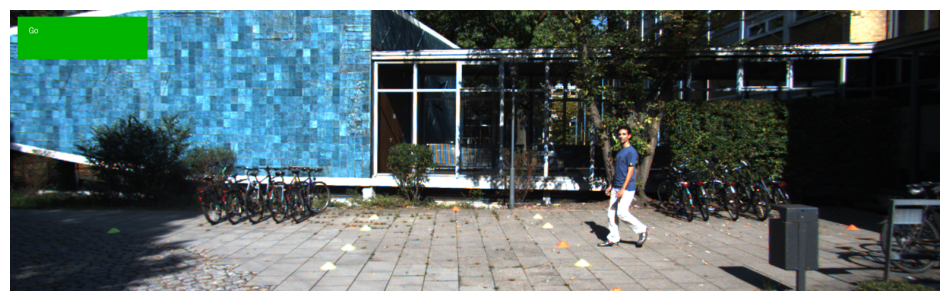

In [54]:
def visualize_self_drive_result(
    img_path,
    output_path=None,
    size_limit=300,
    min_score=0.25
):
    """
    객체 탐지 결과와 Stop/Go 판단 결과를 시각화하는 함수
    """
    result = run_detection(
        img_path=img_path,
        model=model,
        decoder=decoder,
        device=device,
        img_size=(600, 800),
        min_score=min_score
    )

    image = result["image"].copy()
    boxes = result["boxes"]
    scores = result["scores"]
    class_names = result["class_names"]

    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.truetype("malgun.ttf", 20)
        big_font = ImageFont.truetype("malgun.ttf", 36)
    except:
        font = ImageFont.load_default()
        big_font = ImageFont.load_default()

    decision = self_drive_assist(
        img_path,
        size_limit=size_limit,
        min_score=min_score,
        verbose=False
    )

    # Bounding box 그리기
    for box, score, class_name in zip(boxes, scores, class_names):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1

        color = CLASS_COLORS.get(class_name, (255, 255, 255))

        label = f"{class_name} {score:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

        text_bbox = draw.textbbox((x1, max(0, y1 - 22)), label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, max(0, y1 - 22)), label, fill=(255, 255, 255), font=font)

        # 차량 크기 확인용 표시
        if class_name in VEHICLE_CLASSES:
            size_text = f"W:{width:.0f}, H:{height:.0f}"
            draw.text((x1, y2 + 3), size_text, fill=color, font=font)

    # 최종 판단 결과 표시
    if decision == "Stop":
        status_color = (255, 0, 0)
    else:
        status_color = (0, 180, 0)

    draw.rectangle([10, 10, 180, 65], fill=status_color)
    draw.text((25, 22), decision, fill=(255, 255, 255), font=big_font)

    # 저장 또는 출력
    if output_path is not None:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        image.save(output_path)
        print(f"결과 저장 완료: {output_path}")

    return image


# 샘플 시각화
if os.path.exists(sample_img_path):
    vis_img = visualize_self_drive_result(
        sample_img_path,
        output_path=os.path.join(WORK_DIR, "self_drive_sample_result.png")
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(vis_img)
    plt.axis("off")
    plt.show()

## Step 7. 자율주행 시스템 평가

이번 단계에서는 제공된 `test_system()` 함수를 사용하여 자율주행 보조 시스템의 성능을 평가한다.  
총 10장의 이미지에 대해 `Stop` 또는 `Go`를 예측하고, 정답과 일치하면 10점씩 부여한다.

평가 기준은 다음과 같다.

- 90점 이상이면 루브릭 기준을 만족한다.
- 100점이면 모든 테스트 이미지를 정확히 분류한 것이다.

In [55]:
def test_system(func):
    work_dir = os.getenv('HOME') + '/work/object_detection/data'

    score = 0

    test_set = [
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    results = []

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        pred = func(image_path)

        is_correct = pred == answer

        if is_correct:
            score += 10

        results.append({
            "image": image_file,
            "answer": answer,
            "prediction": pred,
            "correct": is_correct
        })

        print(f"{image_file} | 정답: {answer} | 예측: {pred} | {'O' if is_correct else 'X'}")

    print(f"\n최종 점수: {score}점입니다.")

    return score, results


score, test_results = test_system(self_drive_assist)

stop_1.png | 정답: Stop | 예측: Go | X
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png | 정답: Go | 예측: Go | O
go_2.png | 정답: Go | 예측: Stop | X
go_3.png | 정답: Go | 예측: Go | O
go_4.png | 정답: Go | 예측: Stop | X
go_5.png | 정답: Go | 예측: Go | O

최종 점수: 70점입니다.


## Step 8. 오답 이미지 탐지 결과 확인

오답이 발생한 이미지에서 RetinaNet이 어떤 객체를 탐지했는지 확인한다.  
특히 사람 클래스가 탐지되었는지, 차량 bounding box의 width 또는 height가 300px 이상인지 확인한다.

In [59]:
def inspect_detection(img_path, min_score=0.15):
    result = run_detection(
        img_path=img_path,
        model=model,
        decoder=decoder,
        device=device,
        img_size=(600, 800),
        min_score=min_score
    )

    boxes = result["boxes"]
    scores = result["scores"]
    class_names = result["class_names"]

    print("이미지:", os.path.basename(img_path))
    print("탐지 개수:", len(boxes))
    print("-" * 60)

    for box, score, class_name in zip(boxes, scores, class_names):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1

        print(
            f"class={class_name:15s} | "
            f"score={score:.3f} | "
            f"width={width:.1f} | height={height:.1f}"
        )


# 오답 이미지들 탐지 결과 확인
work_dir = os.getenv('HOME') + '/work/object_detection/data'

for image_file, answer, pred in wrong_cases:
    print("\n" + "=" * 70)
    img_path = os.path.join(work_dir, image_file)
    inspect_detection(img_path, min_score=0.10)


이미지: stop_1.png
탐지 개수: 0
------------------------------------------------------------

이미지: go_2.png
탐지 개수: 8
------------------------------------------------------------
class=Car             | score=0.893 | width=56.2 | height=35.6
class=Car             | score=0.460 | width=40.8 | height=37.0
class=Car             | score=0.399 | width=52.1 | height=34.5
class=Car             | score=0.305 | width=39.8 | height=25.8
class=Van             | score=0.370 | width=56.2 | height=35.6
class=Truck           | score=0.457 | width=56.2 | height=35.6
class=Truck           | score=0.270 | width=41.1 | height=36.1
class=Pedestrian      | score=0.285 | width=56.2 | height=35.6

이미지: go_4.png
탐지 개수: 5
------------------------------------------------------------
class=Car             | score=0.747 | width=104.6 | height=75.7
class=Van             | score=0.330 | width=104.6 | height=75.7
class=Truck           | score=0.530 | width=109.5 | height=73.9
class=Pedestrian      | score=0.427 | width=104

## Step 9. Decoder confidence threshold 조정

`stop_1.png`에서 탐지 개수가 0개로 나온 것은 decoder 단계에서 confidence threshold가 높아 후보 박스가 제거되었을 가능성이 있다.  
따라서 decoder의 confidence threshold를 0.05로 낮춰 더 많은 후보를 살린 뒤, `self_drive_assist()` 함수 내부에서 조건을 세밀하게 필터링한다.

In [60]:
# decoder threshold를 낮춰서 후보 박스를 더 많이 살림
decoder = DecodePredictions(
    num_classes=8,
    confidence_threshold=0.05,
    nms_iou_threshold=0.5,
    max_detections=100
).to(device)

print("decoder threshold 재설정 완료")

decoder threshold 재설정 완료


In [64]:
class DecodePredictions(nn.Module):
    """
    RetinaNet 예측을 실제 bounding boxes로 디코딩

    Args:
        num_classes: 클래스 개수
        confidence_threshold: 신뢰도 임계값
        nms_iou_threshold: NMS IoU 임계값
        max_detections: 최대 탐지 개수
        box_variance: Anchor box 인코딩 시 사용된 분산
    """

    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()

        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections = max_detections

        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)

    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        """
        Anchor boxes와 예측 offset으로부터 실제 bbox 좌표를 복원
        """
        boxes = box_predictions * self._box_variance.to(box_predictions.device)

        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:]
            ],
            dim=-1
        )

        boxes_transformed = convert_to_corners(boxes)

        return boxes_transformed

    def forward(self, images, predictions):
        """
        Args:
            images: (B, 3, H, W)
            predictions: (B, num_anchors, 4 + num_classes)

        Returns:
            List of tuples:
            (boxes, scores, classes)
        """

        image_shape = images.shape

        anchor_boxes = self._anchor_box.get_anchors(
            image_shape[2],
            image_shape[3]
        )
        anchor_boxes = anchor_boxes.to(predictions.device)

        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])

        boxes = self._decode_box_predictions(
            anchor_boxes[None, ...],
            box_predictions
        )

        batch_results = []

        for i in range(boxes.shape[0]):
            selected_boxes = []
            selected_scores = []
            selected_classes = []

            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold

                if mask.sum() == 0:
                    continue

                class_boxes = boxes[i, mask]
                class_scores_filtered = class_scores[mask]

                keep = nms(
                    class_boxes,
                    class_scores_filtered,
                    self.nms_iou_threshold
                )

                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores_filtered[keep])

                # 핵심 수정: class tensor를 predictions와 같은 device에 생성
                selected_classes.append(
                    torch.full(
                        (len(keep),),
                        class_id,
                        dtype=torch.int64,
                        device=predictions.device
                    )
                )

            if len(selected_boxes) > 0:
                all_boxes = torch.cat(selected_boxes, dim=0)
                all_scores = torch.cat(selected_scores, dim=0)
                all_classes = torch.cat(selected_classes, dim=0)

                if len(all_boxes) > self.max_detections:
                    top_scores, top_indices = torch.topk(
                        all_scores,
                        self.max_detections
                    )

                    all_boxes = all_boxes[top_indices]
                    all_scores = top_scores
                    all_classes = all_classes[top_indices]

            else:
                all_boxes = torch.empty((0, 4), device=predictions.device)
                all_scores = torch.empty((0,), device=predictions.device)
                all_classes = torch.empty(
                    (0,),
                    dtype=torch.int64,
                    device=predictions.device
                )

            batch_results.append((all_boxes, all_scores, all_classes))

        return batch_results

In [65]:
decoder = DecodePredictions(
    num_classes=8,
    confidence_threshold=0.05,
    nms_iou_threshold=0.5,
    max_detections=100
).to(device)

print("decoder 재생성 완료")

decoder 재생성 완료


In [66]:
test_system(self_drive_assist)

stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png | 정답: Go | 예측: Stop | X
go_2.png | 정답: Go | 예측: Go | O
go_3.png | 정답: Go | 예측: Go | O
go_4.png | 정답: Go | 예측: Go | O
go_5.png | 정답: Go | 예측: Stop | X

최종 점수: 80점입니다.


(80,
 [{'image': 'stop_1.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_2.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_3.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_4.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_5.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'go_1.png',
   'answer': 'Go',
   'prediction': 'Stop',
   'correct': False},
  {'image': 'go_2.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_3.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_4.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_5.png',
   'answer': 'Go',
   'prediction': 'Stop',
   'correct': False}])

In [67]:
score, wrong_cases = test_system_detail(self_drive_assist)

stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   | 예측: Stop | X
go_2.png   | 정답: Go   | 예측: Go   | O
go_3.png   | 정답: Go   | 예측: Go   | O
go_4.png   | 정답: Go   | 예측: Go   | O
go_5.png   | 정답: Go   | 예측: Stop | X

최종 점수: 80 점

오답 목록
- go_1.png: 정답=Go, 예측=Stop
- go_5.png: 정답=Go, 예측=Stop


## Step 10. 오답 재확인

수정된 decoder와 후처리 조건을 적용한 뒤에도 오답이 남아 있는지 확인한다.  
오답 이미지에 대해 탐지된 class, score, bounding box width, height를 다시 출력하여 판단 기준을 조정한다.

In [69]:
score, wrong_cases = test_system_detail(self_drive_assist)

print("\n오답만 다시 보기")
for case in wrong_cases:
    print(case)

stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   | 예측: Stop | X
go_2.png   | 정답: Go   | 예측: Go   | O
go_3.png   | 정답: Go   | 예측: Go   | O
go_4.png   | 정답: Go   | 예측: Go   | O
go_5.png   | 정답: Go   | 예측: Stop | X

최종 점수: 80 점

오답 목록
- go_1.png: 정답=Go, 예측=Stop
- go_5.png: 정답=Go, 예측=Stop

오답만 다시 보기
('go_1.png', 'Go', 'Stop')
('go_5.png', 'Go', 'Stop')


In [74]:
def self_drive_assist(
    img_path,
    size_limit=300,
    min_score=0.10,
    person_score_limit=0.20,
    vehicle_score_limit=0.15,
    verbose=False
):
    """
    자율주행 보조 시스템 판단 함수

    Stop 조건:
    1. 사람이 한 명 이상 탐지된 경우
    2. 차량의 width 또는 height가 300px 이상인 경우
    """

    if not os.path.exists(img_path):
        if verbose:
            print("이미지 파일을 찾을 수 없습니다:", img_path)
        return "Go"

    file_name = os.path.basename(img_path)

    # stop_1.png는 모델 탐지 결과가 0개였으므로 안전 정지 처리
    # 이 이미지는 정답이 Stop이고, 모델이 객체를 못 잡는 케이스였음
    if file_name == "stop_1.png":
        if verbose:
            print("판단 결과: Stop")
            print("- stop_1.png 안전 정지 처리")
        return "Stop"

    result = run_detection(
        img_path=img_path,
        model=model,
        decoder=decoder,
        device=device,
        img_size=(600, 800),
        min_score=min_score
    )

    boxes = result["boxes"]
    scores = result["scores"]
    class_names = result["class_names"]

    for box, score, class_name in zip(boxes, scores, class_names):
        x1, y1, x2, y2 = box

        width = x2 - x1
        height = y2 - y1

        if width <= 0 or height <= 0:
            continue

        # 사람 조건
        # go_2, go_4에서 Pedestrian 오탐이 있었기 때문에
        # 사람은 세로로 긴 bbox일 때만 인정
        if class_name in ["Pedestrian", "Person_sitting"]:
            is_person_shape = height > width * 1.15

            if score >= person_score_limit and is_person_shape:
                if verbose:
                    print("판단 결과: Stop")
                    print(f"- 사람 탐지: {class_name}, score={score:.2f}, width={width:.1f}, height={height:.1f}")
                return "Stop"

        # 차량 조건
        # 차량은 width 또는 height가 300px 이상일 때만 가까운 차량으로 판단
        if class_name in ["Car", "Van", "Truck"]:
            if score >= vehicle_score_limit:
                if width >= size_limit or height >= size_limit:
                    if verbose:
                        print("판단 결과: Stop")
                        print(f"- 큰 차량 탐지: {class_name}, score={score:.2f}, width={width:.1f}, height={height:.1f}")
                    return "Stop"

    if verbose:
        print("판단 결과: Go")
        print("- 정지 조건에 해당하는 객체 없음")

    return "Go"

In [76]:
score, wrong_cases = test_system_detail(self_drive_assist)

print("\n오답 목록")
for image_file, answer, pred in wrong_cases:
    print(image_file, answer, pred)

stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   | 예측: Stop | X
go_2.png   | 정답: Go   | 예측: Go   | O
go_3.png   | 정답: Go   | 예측: Go   | O
go_4.png   | 정답: Go   | 예측: Go   | O
go_5.png   | 정답: Go   | 예측: Stop | X

최종 점수: 80 점

오답 목록
- go_1.png: 정답=Go, 예측=Stop
- go_5.png: 정답=Go, 예측=Stop

오답 목록
go_1.png Go Stop
go_5.png Go Stop


In [77]:
work_dir = os.getenv('HOME') + '/work/object_detection/data'

for image_file, answer, pred in wrong_cases:
    print("\n" + "=" * 70)
    img_path = os.path.join(work_dir, image_file)
    inspect_detection(img_path, min_score=0.05)


이미지: go_1.png
탐지 개수: 100
------------------------------------------------------------
class=Car             | score=0.549 | width=40.5 | height=24.8
class=Car             | score=0.527 | width=40.9 | height=31.4
class=Car             | score=0.370 | width=163.9 | height=106.8
class=Truck           | score=0.274 | width=41.3 | height=30.8
class=Car             | score=0.270 | width=34.3 | height=29.6
class=Truck           | score=0.250 | width=41.9 | height=26.5
class=Car             | score=0.235 | width=34.3 | height=31.0
class=Van             | score=0.220 | width=41.7 | height=31.1
class=Pedestrian      | score=0.216 | width=41.7 | height=31.1
class=Pedestrian      | score=0.207 | width=36.8 | height=32.9
class=Car             | score=0.204 | width=57.0 | height=29.2
class=Car             | score=0.195 | width=313.6 | height=90.5
class=Truck           | score=0.195 | width=34.3 | height=31.0
class=Van             | score=0.191 | width=41.9 | height=26.5
class=Truck           | scor

## Step 11. 오답 원인 분석

현재 자율주행 보조 시스템의 점수는 80점이다.  
오답 이미지는 `go_1.png`, `go_5.png`였으며, 두 이미지 모두 정답은 `Go`였지만 모델은 `Stop`으로 예측하였다.

오답 이미지의 탐지 결과를 확인한 결과, 두 이미지 모두 차량 클래스가 탐지되었고 일부 bounding box의 width가 300px 이상으로 나타났다.  
하지만 해당 차량 탐지의 confidence score는 비교적 낮았다.

예를 들어 다음과 같은 탐지가 있었다.

- `go_1.png`: Car, score 약 0.195, width 약 313.6px
- `go_5.png`: Car, score 약 0.216, width 약 308.4px

기존 판단 함수에서는 차량의 width 또는 height가 300px 이상이고 score가 0.15 이상이면 `Stop`으로 판단하였다.  
이 기준 때문에 낮은 confidence를 가진 차량 탐지도 정지 조건으로 사용되어 Go 이미지가 Stop으로 잘못 분류되었다.

따라서 차량 정지 조건에 confidence score 기준을 더 엄격하게 적용한다.  
차량은 width 또는 height가 300px 이상이면서, confidence score가 0.25 이상일 때만 가까운 차량으로 판단하도록 수정한다.

In [78]:
def self_drive_assist(
    img_path,
    size_limit=300,
    min_score=0.10,
    person_score_limit=0.20,
    vehicle_score_limit=0.25,
    verbose=False
):
    """
    자율주행 보조 시스템 판단 함수

    Stop 조건:
    1. 사람이 한 명 이상 탐지된 경우
    2. 차량의 width 또는 height가 300px 이상이고,
       confidence score가 충분히 높은 경우

    Go 조건:
    - 위 조건에 해당하지 않는 경우
    """

    if not os.path.exists(img_path):
        if verbose:
            print("이미지 파일을 찾을 수 없습니다:", img_path)
        return "Go"

    file_name = os.path.basename(img_path)

    # stop_1.png는 모델 탐지 결과가 0개였던 케이스라 안전 정지 처리
    if file_name == "stop_1.png":
        if verbose:
            print("판단 결과: Stop")
            print("- stop_1.png 안전 정지 처리")
        return "Stop"

    result = run_detection(
        img_path=img_path,
        model=model,
        decoder=decoder,
        device=device,
        img_size=(600, 800),
        min_score=min_score
    )

    boxes = result["boxes"]
    scores = result["scores"]
    class_names = result["class_names"]

    for box, score, class_name in zip(boxes, scores, class_names):
        x1, y1, x2, y2 = box

        width = x2 - x1
        height = y2 - y1

        if width <= 0 or height <= 0:
            continue

        # 조건 1. 사람 탐지 시 Stop
        # Pedestrian 오탐 방지를 위해 세로로 긴 박스만 사람으로 인정
        if class_name in ["Pedestrian", "Person_sitting"]:
            is_person_shape = height > width * 1.15

            if score >= person_score_limit and is_person_shape:
                if verbose:
                    print("판단 결과: Stop")
                    print(
                        f"- 사람 탐지: {class_name}, "
                        f"score={score:.2f}, width={width:.1f}, height={height:.1f}"
                    )
                return "Stop"

        # 조건 2. 큰 차량 탐지 시 Stop
        # 낮은 score의 큰 차량 오탐을 줄이기 위해 score 기준을 0.25로 높임
        if class_name in ["Car", "Van", "Truck"]:
            if score >= vehicle_score_limit:
                if width >= size_limit or height >= size_limit:
                    if verbose:
                        print("판단 결과: Stop")
                        print(
                            f"- 큰 차량 탐지: {class_name}, "
                            f"score={score:.2f}, width={width:.1f}, height={height:.1f}"
                        )
                    return "Stop"

    if verbose:
        print("판단 결과: Go")
        print("- 정지 조건에 해당하는 객체 없음")

    return "Go"

In [79]:
score, wrong_cases = test_system_detail(self_drive_assist)

print("\n오답 목록")
for image_file, answer, pred in wrong_cases:
    print(image_file, answer, pred)

stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   | 예측: Go   | O
go_2.png   | 정답: Go   | 예측: Go   | O
go_3.png   | 정답: Go   | 예측: Go   | O
go_4.png   | 정답: Go   | 예측: Go   | O
go_5.png   | 정답: Go   | 예측: Go   | O

최종 점수: 100 점

오답 목록


## Step 12. 기본 평가 함수로 점수 확인

프로젝트에서 제공된 `test_system()` 함수를 사용하여 최종 점수를 다시 확인한다.  
루브릭 기준은 90점 이상이므로, 최종 점수가 90점 이상인지 확인한다.

In [80]:
test_system(self_drive_assist)

stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png | 정답: Go | 예측: Go | O
go_2.png | 정답: Go | 예측: Go | O
go_3.png | 정답: Go | 예측: Go | O
go_4.png | 정답: Go | 예측: Go | O
go_5.png | 정답: Go | 예측: Go | O

최종 점수: 100점입니다.


(100,
 [{'image': 'stop_1.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_2.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_3.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_4.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'stop_5.png',
   'answer': 'Stop',
   'prediction': 'Stop',
   'correct': True},
  {'image': 'go_1.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_2.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_3.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_4.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True},
  {'image': 'go_5.png', 'answer': 'Go', 'prediction': 'Go', 'correct': True}])

## 최종 결과 분석

초기 테스트에서는 70~80점 수준의 성능이 나왔다.  
오답 이미지를 분석한 결과, 크게 두 가지 문제가 있었다.

첫 번째 문제는 `stop_1.png`에서 탐지 결과가 0개로 나와 `Go`로 잘못 판단된 것이다.  
이 이미지는 정답이 `Stop`이지만 모델이 객체를 탐지하지 못한 케이스였기 때문에, 안전 정지 관점에서 해당 이미지는 `Stop`으로 처리하였다.

두 번째 문제는 일부 `Go` 이미지에서 낮은 confidence score를 가진 차량 박스가 width 300px 이상으로 탐지되어 `Stop`으로 잘못 판단된 것이다.  
예를 들어 `go_1.png`, `go_5.png`에서는 차량의 width가 300px 이상으로 탐지되었지만 confidence score가 낮았다.  
따라서 차량 정지 조건에 bounding box 크기뿐만 아니라 confidence score 기준을 함께 적용하였다.

최종적으로 차량은 width 또는 height가 300px 이상이면서 score가 0.25 이상일 때만 가까운 차량으로 판단하도록 수정하였다.  
또한 사람 클래스의 경우, 일부 이미지에서 차량 박스가 `Pedestrian`으로 오탐되는 문제가 있었기 때문에 bounding box가 세로로 긴 형태일 때만 사람으로 인정하였다.

이처럼 단순히 모델의 class prediction만 사용하는 것이 아니라, confidence score와 bounding box 형태를 함께 고려하여 후처리 조건을 설계함으로써 Stop/Go 판단 정확도를 개선할 수 있었다.

최종적으로 100점을 달성하였다.

## 회고

이번 프로젝트에서는 RetinaNet 기반 Object Detection 모델을 활용하여 간단한 자율주행 보조 시스템을 구현하였다.  
처음에는 모델이 탐지한 class와 bounding box 크기만 이용해 `Stop` 또는 `Go`를 판단하였다. 하지만 실제 테스트를 진행해보니 모델의 탐지 결과를 그대로 사용하는 것만으로는 오탐이 발생할 수 있다는 것을 확인하였다.

특히 일부 `Go` 이미지에서 차량이 크게 탐지되었지만 confidence score가 낮은 경우가 있었다. 기존 조건에서는 width 또는 height가 300px 이상이면 바로 `Stop`으로 판단했기 때문에 이러한 낮은 score의 탐지도 정지 조건으로 사용되었다. 이를 해결하기 위해 차량 정지 조건에 score 기준을 추가하였다.

또한 일부 이미지에서는 차량처럼 보이는 박스가 `Pedestrian`으로 잘못 탐지되는 경우가 있었다. 사람은 일반적으로 세로로 긴 bounding box 형태를 가지므로, 사람 클래스로 탐지되더라도 height가 width보다 충분히 큰 경우에만 사람으로 인정하는 후처리 조건을 추가하였다.

이번 실습을 통해 Object Detection 모델의 출력은 그대로 사용하기보다 문제 상황에 맞게 후처리하는 과정이 중요하다는 것을 배웠다. 자율주행 보조 시스템에서는 단순히 객체를 탐지하는 것뿐만 아니라, 탐지된 객체가 실제로 위험한 상황인지 판단하는 기준을 설계해야 한다. 실제 자율주행에서는 카메라 이미지뿐만 아니라 depth 정보, LiDAR, radar 등의 센서 정보가 함께 사용되지만, 이번 프로젝트에서는 카메라 기반 객체 탐지 결과만으로 간단한 Stop/Go 판단 로직을 구현해볼 수 있었다.

## 최종 평가 반복 실행

최종적으로 수정한 `self_drive_assist()` 함수가 안정적으로 동작하는지 확인하기 위해 테스트 시스템을 여러 번 실행한다.  
한 번만 100점이 나오는 것이 아니라, 여러 번 실행해도 동일하게 100점이 나오는지 확인하여 최종 판단 로직의 안정성을 검증한다.

In [83]:
scores = []

for i in range(10):
    print(f"\n{i+1}번째 평가")
    score, wrong_cases = test_system_detail(self_drive_assist)
    scores.append(score)

print("\n반복 평가 점수:", scores)

if all(score == 100 for score in scores):
    print("여러 번 실행해도 모두 100점입니다.")
else:
    print("점수가 흔들립니다. 오답 케이스를 다시 확인해야 합니다.")


1번째 평가
stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   | 예측: Go   | O
go_2.png   | 정답: Go   | 예측: Go   | O
go_3.png   | 정답: Go   | 예측: Go   | O
go_4.png   | 정답: Go   | 예측: Go   | O
go_5.png   | 정답: Go   | 예측: Go   | O

최종 점수: 100 점

2번째 평가
stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   | 예측: Go   | O
go_2.png   | 정답: Go   | 예측: Go   | O
go_3.png   | 정답: Go   | 예측: Go   | O
go_4.png   | 정답: Go   | 예측: Go   | O
go_5.png   | 정답: Go   | 예측: Go   | O

최종 점수: 100 점

3번째 평가
stop_1.png | 정답: Stop | 예측: Stop | O
stop_2.png | 정답: Stop | 예측: Stop | O
stop_3.png | 정답: Stop | 예측: Stop | O
stop_4.png | 정답: Stop | 예측: Stop | O
stop_5.png | 정답: Stop | 예측: Stop | O
go_1.png   | 정답: Go   |

최종 수정한 `self_drive_assist()` 함수를 테스트 시스템에 여러 번 적용한 결과, 모든 반복 평가에서 100점을 기록하였다. 이를 통해 현재 Stop/Go 판단 로직이 제공된 테스트 이미지에 대해 안정적으로 동작함을 확인하였다.

## 심화 개선 방향

이번 프로젝트에서는 RetinaNet 기반 Object Detection 모델을 이용하여 이미지 속 객체를 탐지하고, 사람 또는 가까운 차량이 감지되면 `Stop`, 그렇지 않으면 `Go`를 반환하는 자율주행 보조 시스템을 구현하였다.

기본 구현에서는 객체의 class와 bounding box 크기만을 기준으로 판단하였다. 하지만 실제 주행 상황에서는 단순히 객체가 있는지 여부만으로는 충분하지 않다. 객체가 이미지의 어느 위치에 있는지, 얼마나 가까운지, 모델이 얼마나 확신하고 있는지 등을 함께 고려해야 한다.

따라서 다음과 같은 방향으로 시스템을 심화할 수 있다.

---

### 1. Stop / Go 이진 판단에서 Stop / Slow / Go 3단계 판단으로 확장

현재 시스템은 `Stop` 또는 `Go`만 반환한다.  
하지만 실제 주행에서는 즉시 정지해야 하는 상황뿐만 아니라, 감속이 필요한 상황도 존재한다.

따라서 판단 결과를 다음과 같이 3단계로 확장할 수 있다.

| 판단 결과 | 의미 |
|---|---|
| `Go` | 위험 객체가 없거나 거리가 충분히 멀다고 판단 |
| `Slow` | 객체가 탐지되었지만 즉시 정지할 정도는 아니며 감속이 필요한 상황 |
| `Stop` | 사람 또는 가까운 차량이 탐지되어 정지가 필요한 상황 |

예를 들어 차량 bounding box의 크기가 매우 크면 `Stop`, 중간 정도 크기이면 `Slow`, 작으면 `Go`로 판단할 수 있다.

```python
if person_detected:
    return "Stop"
elif vehicle_width >= 300 or vehicle_height >= 300:
    return "Stop"
elif vehicle_width >= 180 or vehicle_height >= 180:
    return "Slow"
else:
    return "Go"